### Parameters

In [1]:
# import
import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace
from matplotlib.gridspec import GridSpec

RATE_REFERENCE_LINES = [
    (1, "1/s"),
    (1 / 60, "1/min"),
    (1 / 3600, "1/h"),
    (1 / (24 * 3600), "1/d"),
    (1 / (30 * 24 * 3600), "1/month"),
    (1 / (365 * 24 * 3600), "1/y"),
]


def add_rate_reference_lines(ax, x=0.98, fontsize=7):
    y_limits = ax.get_ylim()
    for rate_hz, rate_label in RATE_REFERENCE_LINES:
        ax.axhline(rate_hz, color="0.35", linestyle=":", linewidth=1)
        ax.text(
            x,
            rate_hz,
            rate_label,
            transform=ax.get_yaxis_transform(),
            color="0.25",
            fontsize=fontsize,
            ha="right",
            va="bottom",
            clip_on=True,
        )
    ax.set_ylim(y_limits)


def add_rate_reference_contours(ax, x_values, y_values, rate_values, color="cyan", fontsize=8):
    finite_rates = np.ma.masked_invalid(rate_values)
    if finite_rates.count() == 0:
        return None
    rate_min = finite_rates.min()
    rate_max = finite_rates.max()
    contour_levels = sorted(
        rate_hz for rate_hz, _ in RATE_REFERENCE_LINES if rate_min <= rate_hz <= rate_max
    )
    if not contour_levels:
        return None
    x_limits = ax.get_xlim()
    y_limits = ax.get_ylim()
    contour = ax.contour(
        x_values,
        y_values,
        finite_rates,
        levels=contour_levels,
        colors=color,
        linewidths=1.4,
    )
    ax.clabel(contour, fmt=dict(RATE_REFERENCE_LINES), fontsize=fontsize, inline=True)
    ax.set_xlim(x_limits)
    ax.set_ylim(y_limits)
    return contour


In [2]:
# Experimental values

# Select parameter set: 0 = current SW, 1 = current DD, 2 = optimistic, 3 = very optimistic, 4 = Welinq
par = 1

# ------------------------------
# Quantum Memory Parameters
# ------------------------------

eta_AFC0 = [0.3, 0.6, 0.7, 0.9, 0.9][par]       # AFC efficiency at zero delay
eta_CP = [0.7, 0.8, 0.9, 0.98, 1][par]          # Control pulse efficiency
eta_m0 = eta_AFC0 * eta_CP * eta_CP             # Memory efficiency at zero delay

cycle_mem = 1                                   # Memory cycle duration [s]
prep_mem = [0.35, 0.3, 0.25, 0.2, 0.1][par]     # Time needed to reinitialize memory [s]
eta_duty_mem = 1 - prep_mem / cycle_mem         # Duty cycle of the memory

T_acceptance = 6e-6                            # Time window for entering AFC before spin wave storage [s]
lat = 150e-6                                    # Memory latency after a success [s]

NF = [8.2e-4, 8.2e-4, 6e-4, 5e-4, 5e-4][par]    # Noise floor
tau_eff = [2e-3, 4e-3, 8e-3, 20e-3, 20e-3][par] # Effective memory lifetime with DD [s]

# ------------------------------
# SPDC Source Parameters
# ------------------------------
eta_h = [0.3, 0.5, 0.6, 0.8, 0.6][par]           # Heralding efficiency
P = 2                                           # SPDC pump power [mW]
a = 0.00315 # sam said 6, I think this is wrong                                           # g^2(0) model parameter
bright = 24300  # sam said 1_700_000, this is wrong right ?                              # Brightness [counts/s/mW]
M = 15                                          # Multimode scaling factor

# Also why factor 2 here ?
# Rid0 = 2 * bright / M                           # Heralding rate at source output [Hz/mW]

# Sam made a mistake here ?
# #g2 = 1 + 1 / (a * P)                            # Cross-correlation function

eta_duty_chopper = [20/33, 20/33, 22/33, 25/33, 1][par] # Duty cycle of the chopper (locking)
eta_phase_stab = 3/4                       # Phase stabilization time divided by time of phase stab + time of photon generation

# ------------------------------
# Sync & Timing Capabilities
# ------------------------------
T_max = tau_eff * 1                                # Max waiting time for a match [s]

# ------------------------------
# Optical Transmission Efficiencies
# ------------------------------
eta_T1 = [0.6, 0.7, 0.8, 0.95, 1][par]          # Source-to-memory
eta_T2 = [0.5, 0.6, 0.8, 0.90, 0.9][par]        # Memory-to-filter
eta_T3 = [0.7, 0.8, 0.90, 0.95, 1][par]         # Filter-to-fiber
eta_path = eta_T1 * eta_T2 * eta_T3                      # Total path efficiency

# ------------------------------
# Detection and Visibility
# ------------------------------
fwhm_phase = 0.25                          # Phase distribution fwhm in radians, for the model exp(-sigma_phase^2)

etaOv = [0.9, 0.9, 0.95, 0.99, 0.99][par]       # Mode overlap
etaclass = 0.87
eta_d = [0.85, 0.85, 0.90, 0.95, 0.9][par]       # Detector efficiency


# ------------------------------
# Fiber Channel Specs
# ------------------------------
L = 50                                      # Fiber length [km]
alpha = 0.2                                 # Attenuation [dB/km]
fib = 10 ** (-alpha * L / 10)               # Fiber transmission

c = 299_792.458                             # Speed of light [km/s]
n = 1.5                                     # Refractive index of fiber
T_L = ( L * n) / c                          # one way-trip communication time [s]

In [3]:
params_felix = {
    "eta_AFC0": eta_AFC0,
    "eta_CP": eta_CP,
    "cycle_mem": cycle_mem,
    "prep_mem": 0.6,            # swappinger
    "T_acceptance": 6e-6,
    "lat": 200e-6,              # swappinger
    "NF": 3.5e-5,               # swappinger
    "tau_eff": tau_eff,
    "eta_h": eta_h,
    "P": 0.003,
    "a": 0.00315,
    "bright": 21000,
    "M": M,
    "eta_duty_chopper": 18/33,
    "eta_phase_stab": eta_phase_stab,
    "T_max": T_max,
    "eta_T1": eta_T1,
    "eta_T2": eta_T2,
    "eta_T3": eta_T3,
    "etaOv": etaOv,
    "eta_d": eta_d,      
    "L": 25,
    "alpha": alpha,
    "c": c,
    "n": n,
    "sigma_phase": fwhm_phase / 2.355,
    "etaclass": etaclass,
    "mu1": 0.01,
}

In [4]:
params_sam = {
    "eta_AFC0": eta_AFC0,
    "eta_CP": eta_CP,
    "cycle_mem": cycle_mem,
    "prep_mem": prep_mem,
    "T_acceptance": T_acceptance,
    "lat": lat,
    "NF": NF,
    "tau_eff": tau_eff,
    "eta_h": eta_h,
    "P": 18,
    "a": a,
    "bright": bright,
    "M": M,
    "eta_duty_chopper": eta_duty_chopper,
    "eta_phase_stab": eta_phase_stab,
    "T_max": T_max,
    "eta_T1": eta_T1,
    "eta_T2": eta_T2,
    "eta_T3": eta_T3,
    "etaOv": etaOv,
    "eta_d": eta_d,
    "L": 50,
    "alpha": alpha,
    "c": c,
    "n": n,
    "sigma_phase": fwhm_phase / 2.355,
    "etaclass": etaclass,
    "mu1": 0.01, 
}

In [5]:
params_current = {
    "eta_AFC0": 0.1,
    "eta_CP": 0.6,
    "cycle_mem": cycle_mem,
    "prep_mem": 0.6,            # swappinger
    "T_acceptance": 6e-6,
    "lat": 200e-6,              # swappinger
    "NF": 3.5e-5,               # swappinger
    "tau_eff": tau_eff,
    "eta_h": 0.2,               # Swappinger
    "P": 3.55,
    "a": 0.00315,
    "bright": 24300,
    "M": M,
    "eta_duty_chopper": 18/33,
    "eta_phase_stab": eta_phase_stab,
    "T_max": T_max,
    "eta_T1": 0.6,
    "eta_T2": 0.1,
    "eta_T3": 0.9,
    "etaOv": etaOv,
    "eta_d": eta_d,      # swappinger
    "L": 1,
    "alpha": alpha,
    "c": c,
    "n": n,
    "sigma_phase": fwhm_phase / 2.355,
    "etaclass": etaclass,
    "etapath": 0.1,
    "mu1": 0.01,
}

In [6]:
# Choose param
params = params_sam.copy()

# Repeater made of double chain links


## One link


#### One link with double chain class

In [7]:
class DoubleChainLink:
    def __init__(self, params, memory_modes = 1,print_rate = False):
        self.params = SimpleNamespace(**params)
        self.calculate_params()
        self.print_rate = print_rate
        self.memory_modes = memory_modes

    def calculate_params(self):
        """Calculate parameters that depend on other parameters."""
        self.params.eta_m0 = self.params.eta_AFC0 * self.params.eta_CP**2
        self.params.eta_duty_mem = 1 - self.params.prep_mem / self.params.cycle_mem
        self.params.Rid0 = self.params.bright / self.params.M
        self.params.g2 = 1 + 1 / (self.params.P * self.params.a)
        self.params.T_max = max(self.params.tau_eff * 0.5, 500e-6)
        self.params.eta_path = self.params.eta_T1 * self.params.eta_T2 * self.params.eta_T3
        self.params.fib = 10 ** (-self.params.alpha * self.params.L / 10)
        self.params.T_L = self.params.L * self.params.n / self.params.c
        self.params.NF = self.params.mu1 * self.params.eta_T2 * self.params.eta_T3 * self.params.eta_d * self.params.eta_m0

    # time dependent functions

    def efficiency(self, t):
        storage_time = 2 * self.params.T_L + t
        return self.params.eta_m0 * np.exp(-storage_time**2 / self.params.tau_eff**2)

    def g2_sw_old(self, t):
        """Cross-correlation function as a function of storage time."""
        # No stored signal means uncorrelated detections, so g2 tends to 1.
        return 1 + self.params.eta_h * self.efficiency(t) * self.params.eta_T2 * self.params.eta_T3 * self.params.eta_d / (self.params.eta_h * self.params.eta_AFC0 * self.params.eta_T2 * self.params.eta_T3 * self.params.eta_d / self.params.g2 + self.params.NF)

    def g2_sw(self,t):
        # from swappinger PRX
        return self.params.g2 * (self.params.eta_h * self.efficiency(t) * self.params.eta_T2 * self.params.eta_T3 * self.params.eta_d / self.params.NF + 1) / (self.params.g2 + self.params.eta_h * self.efficiency(t) * self.params.eta_T2 * self.params.eta_T3 * self.params.eta_d / self.params.NF)

    def V(self, t):
        """Visibility as a function of storage time."""
        return (self.g2_sw(t) - 1) / (self.g2_sw(t) + 1) * np.exp(- (self.params.sigma_phase**2) /2 ) * self.params.etaOv **2 * self.params.etaclass
    
    def p10(self, t):
        """Probability to detect a photon on the left of the link, and no photon on the right, conditioned on idler detection."""
        return self.efficiency(t) * self.params.eta_path * self.params.eta_d * self.params.eta_h / 2 + self.params.NF

    def p01(self, t):
        return self.p10(t)

    def p11(self, t):
        """Probability to detect a photon on the left of the link, and a photon on the right, conditioned on idler detection."""
        return 4 * self.p10(t) * self.p10(t) * (self.g2_sw(t) - 1) / (self.g2_sw(t) * self.g2_sw(t))

    def p00(self, t):
        return np.maximum(1 - self.p01(t) - self.p10(t) - self.p11(t), 0)

    def detected_single_weight(self, t):
        return self.p01(t) + self.p10(t)

    def D_link(self, t_a, t_b):
        """Accepted double-chain readout weight, including useful and bad accepted sectors."""
        useful = self.detected_single_weight(t_a) * self.detected_single_weight(t_b)
        bad = self.p11(t_a) * self.p00(t_b) + self.p00(t_a) * self.p11(t_b)
        return useful + 2 * bad

    def q_pop(self, t):
        """ Part of the density matrix population in the |10><10| and |01><01| subspace, conditioned on idler detection. No vacuum there"""
        return (2 * self.p10(t))/(2 * self.p10(t) + self.p11(t))

    def F_k_(self, k):
        """Accepted-readout fidelity for an internal delay of k communication rounds."""
        t = 2 * k * self.params.T_L
        D = self.D_link(0, t)
        useful = self.detected_single_weight(0) * self.detected_single_weight(t)
        return np.nan if D == 0 else useful * (1 + self.V(0) * self.V(t)) / (2 * D)

    def w_(self, k):
        return self.p**2 if k == 0 else 2 * self.p**2 * self.q**k

    def get_rates(self):
        self.N = np.floor(self.params.T_max / 2 / self.params.T_L)                  # Number of rounds before giving up
        self.Gamma_1 = self.params.Rid0 * self.params.P * self.params.fib * self.params.eta_d * 2     # heralding rate of idlers in central station
        self.p = 1 - np.exp(- self.Gamma_1 * self.params.T_acceptance)       # Probability of at least one heralding event in T_acceptance
        self.q = 1 - self.p                                                              # Probability of no heralding event in T_acceptance
        
        if self.memory_modes == 1:
            self.p_ready_conditioned_non_empty = self.p ** 2 / (1 - self.q**2) + 2*self.p*self.q/(1 - self.q**2) * (1 - self.q**self.N)             # Probability of being ready given a non-empty queue
            self.p_ready = self.p_ready_conditioned_non_empty * (1 - self.q**2)

                # average time of a cycle
            self.n_first = 1 / (1-self.q**2)                      # Average number of rounds until first attempt 
            self.n_extra = (1 - self.q**self.N) / self.p                    # Extra number of rounds until success, given that we have one attempt with one heralding event

            self.n_cycle = self.n_first + 2*self.p*self.q/(1 - self.q**2) * self.n_extra  # Average number of rounds until attempt, including the extra rounds after the first heralding event

            self.T_cycle = self.n_cycle * 2 * self.params.T_L  + self.p_ready_conditioned_non_empty*self.params.lat        # Average cycle time, including communication time and latency

            # Final ready rate
            self.Gamma_ready = self.p_ready_conditioned_non_empty / self.T_cycle * self.params.eta_duty_mem * self.params.eta_duty_chopper * self.params.eta_phase_stab

            # probability to have successfuly detected all the photons given a ready event
            self.eta_avg = (self.p**2 * self.efficiency(0)**2 + 2*self.p*self.q*sum(self.p*self.q**(k-1)*self.efficiency(0)* self.efficiency(2*(k)*self.params.T_L) for k in range(1, int(self.N)+1))) / self.p_ready
            self.p_succ = self.params.eta_h**2 * self.params.eta_path**2 * self.params.eta_d**2 / 2 * self.eta_avg

            # Overall success rate
            self.Gamma_succ = self.Gamma_ready * self.p_succ
        else:
            self.age_step = 2 * self.params.T_L / self.memory_modes
            self.K = max(1, int(np.ceil(self.params.T_max / self.age_step)))
            self.lambda_M = self.memory_modes * self.p / (2 * self.params.T_L)
            self.Gamma_ready = 2 * self.lambda_M * (1 - self.q**self.K) * self.params.eta_duty_mem * self.params.eta_duty_chopper * self.params.eta_phase_stab

            # probability to have successfuly detected all the photons given a ready event
            den_ready = 1 - self.q**self.K
            eta_stored = sum(self.p * self.q**j * self.efficiency(j * self.age_step) for j in range(self.K)) / den_ready
            self.eta_avg = self.efficiency(0) * eta_stored
            self.p_succ = self.params.eta_h**2 * self.params.eta_path**2 * self.params.eta_d**2 / 2 * self.eta_avg
            self.Gamma_succ = self.Gamma_ready * self.p_succ

        

        if self.print_rate:
            print(f"Ready rate: {self.Gamma_ready:.2f} Hz")
            print(f"Success rate: {self.Gamma_succ:.4f} Hz")
            print(f"Number of rounds before giving up: {int(self.N)}")
            print(f"Raw rate at detectors : {self.Gamma_1:.2f} Hz")

    def get_fidelity(self):
        if self.memory_modes == 1:
            num = sum(self.w_(k) * self.detected_single_weight(0) * self.detected_single_weight(2*k*self.params.T_L) * (1 + self.V(0) * self.V(2*k*self.params.T_L)) / 2 for k in range(int(self.N) + 1))
            den = sum(self.w_(k) * self.D_link(0, 2*k*self.params.T_L) for k in range(int(self.N) + 1))
        else:
            num = sum(self.p * self.q**j * self.detected_single_weight(0) * self.detected_single_weight(j * self.age_step) * (1 + self.V(0) * self.V(j * self.age_step)) / 2 for j in range(self.K))
            den = sum(self.p * self.q**j * self.D_link(0, j * self.age_step) for j in range(self.K))
        self.fidelity = np.nan if den == 0 else num / den
        if self.print_rate:
            print(f"Fidelity: {self.fidelity:.4f}")

    def get_fidelity_good_sector(self):
        """Fidelity conditioned on the useful single-excitation sector only."""
        if not hasattr(self, "p"):
            self.get_rates()

        if self.memory_modes == 1:
            num = sum(self.w_(k) * self.efficiency(0) * self.efficiency(2*k*self.params.T_L) * self.q_pop(0) * self.q_pop(2*k*self.params.T_L) * (1 + self.V(0) * self.V(2*k*self.params.T_L)) / 2 for k in range(int(self.N) + 1))
            den = sum(self.w_(k) * self.efficiency(0) * self.efficiency(2*k*self.params.T_L) for k in range(int(self.N) + 1))
        else:
            num = sum(self.p * self.q**j * self.efficiency(0) * self.efficiency(j * self.age_step) * self.q_pop(0) * self.q_pop(j * self.age_step) * (1 + self.V(0) * self.V(j * self.age_step)) / 2 for j in range(self.K))
            den = sum(self.p * self.q**j * self.efficiency(0) * self.efficiency(j * self.age_step) for j in range(self.K))
        self.fidelity_good_sector = np.nan if den == 0 else num / den
        if self.print_rate:
            print(f"Good-sector fidelity: {self.fidelity_good_sector:.4f}")

In [8]:
# Single link calculation
mylink = DoubleChainLink(params, print_rate=True)
mylink.get_rates()
mylink.get_fidelity()
mylink.get_fidelity_good_sector()
print(f"g2_sw : {mylink.g2_sw(0):.2f}")
print(f"g2 source : {mylink.params.g2:.2f}")
print(f"g2_old : {mylink.g2_sw_old(0):.2f}")
print(f"efficiency at 0 delay : {mylink.efficiency(0):.4f} ")
print(f"p10 at 0 delay : {mylink.p10(0):.4e} ")
print(f"p11 at 0 delay : {mylink.p11(0):.4e} ")
print(f"detected raw idler count rate for power of 3.85mW : {mylink.params.Rid0 * 3.85 * mylink.params.eta_d:.4f}")
print(f"pump power : {mylink.params.P} mW")

Ready rate: 3.11 Hz
Success rate: 0.0041 Hz
Number of rounds before giving up: 3
Raw rate at detectors : 4957.20 Hz
Fidelity: 0.5422
Good-sector fidelity: 0.6778
g2_sw : 13.79
g2 source : 18.64
g2_old : 10.48
efficiency at 0 delay : 0.3780 
p10 at 0 delay : 2.8559e-02 
p11 at 0 delay : 2.1938e-04 
detected raw idler count rate for power of 3.85mW : 5301.4500
pump power : 18 mW


#### Rates and fidelities for a single mode

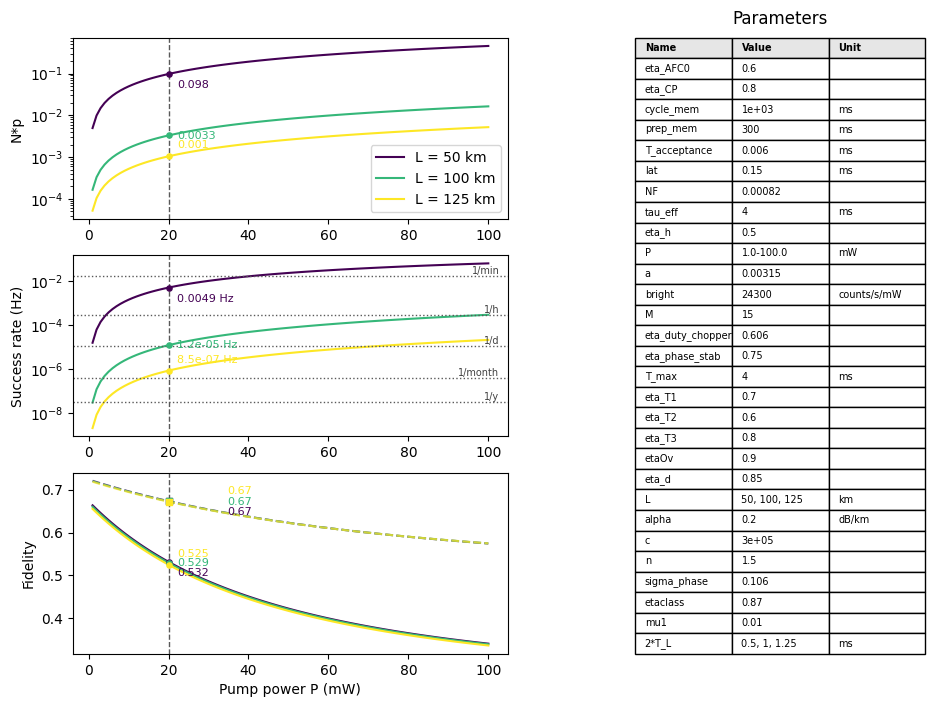

In [9]:
L_scan = [50, 100, 125]
cmap = plt.cm.viridis
norm = plt.Normalize(min(L_scan), max(L_scan))
P_marker = 20
P_scan = np.linspace(1, 100, 100)

table_params = params.copy()
table_params["P"] = f"{P_scan[0]:.1f}-{P_scan[-1]:.1f}"
table_params["L"] = ", ".join(str(L) for L in L_scan)
table_params["2*T_L"] = ", ".join(f"{2 * L * table_params['n'] / table_params['c'] * 1e3:.3g}" for L in L_scan)
time_params = {"cycle_mem", "prep_mem", "T_acceptance", "lat", "tau_eff", "T_max", "T_L"}
param_units = {
    "cycle_mem": "ms",
    "prep_mem": "ms",
    "T_acceptance": "ms",
    "lat": "ms",
    "tau_eff": "ms",
    "P": "mW",
    "bright": "counts/s/mW",
    "Rid0": "Hz/mW",
    "T_max": "ms",
    "L": "km",
    "alpha": "dB/km",
    "T_L": "ms",
    "2*T_L": "ms",
}
table_rows = []
for name, value in table_params.items():
    if name in time_params and isinstance(value, (int, float)):
        value = f"{value * 1e3:.3g}"
    elif isinstance(value, float):
        value = f"{value:.3g}"
    table_rows.append([name, value, param_units.get(name, "")])


fig = plt.figure(figsize=(11, 8))
gs = fig.add_gridspec(3, 2, width_ratios=[3, 2], wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
ax3 = fig.add_subplot(gs[2, 0], sharex=ax1)
ax_table = fig.add_subplot(gs[:, 1])
ax_table.axis("off")

for i, L in enumerate(L_scan):
    color = cmap(norm(L))
    # Scan the pump power
    table_params["L"] = L
    Gamma_ready_scan = []
    Gamma_succ_scan = []
    F_scan = []
    F_good_scan = []
    g2_sw_scan = []
    Np_scan = []

    for P_now in P_scan:
        table_params["P"] = P_now
        mylink = DoubleChainLink(table_params, print_rate=False)
        mylink.get_rates()
        mylink.get_fidelity()
        mylink.get_fidelity_good_sector()
        Gamma_ready_scan.append(mylink.Gamma_ready)
        Gamma_succ_scan.append(mylink.Gamma_succ)
        F_scan.append(mylink.fidelity)
        F_good_scan.append(mylink.fidelity_good_sector)
        g2_sw_scan.append(mylink.g2_sw(0))
        Np_scan.append(mylink.p * mylink.N)

    ready_at_marker = np.interp(P_marker, P_scan, Gamma_ready_scan)
    succ_at_marker = np.interp(P_marker, P_scan, Gamma_succ_scan)
    fidelity_at_marker = np.interp(P_marker, P_scan, F_scan)
    fidelity_good_at_marker = np.interp(P_marker, P_scan, F_good_scan)
    g2_sw_at_marker = np.interp(P_marker, P_scan, g2_sw_scan)
    Np_at_marker = np.interp(P_marker, P_scan, Np_scan)
    label_offset = 8 * (i - (len(L_scan) - 1) / 2)

    #ax1.plot(P_scan, Gamma_ready_scan, color = color, label=f"L = {L} km")
    #ax1.scatter(P_marker, ready_at_marker, color=color, s=14, zorder=3)
    #ax1.annotate(f"{ready_at_marker:.2g} Hz", xy=(P_marker, ready_at_marker), xytext=(6, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")
    #ax1.set_ylabel('Ready rate (Hz)')

    ax1.plot(P_scan, Np_scan, color=color, label=f"L = {L} km")
    ax1.scatter(P_marker, Np_at_marker, color=color, s=14, zorder=3)
    ax1.annotate(f"{Np_at_marker:.2g}", xy=(P_marker, Np_at_marker), xytext=(6, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")
    ax1.set_ylabel('N*p')

    ax2.plot(P_scan, Gamma_succ_scan, color = color, label=f"L = {L} km")
    ax2.scatter(P_marker, succ_at_marker, color=color, s=14, zorder=3)
    ax2.annotate(f"{succ_at_marker:.2g} Hz", xy=(P_marker, succ_at_marker), xytext=(6, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")
    ax2.set_ylabel('Success rate (Hz)')

    ax3.plot(P_scan, F_scan, color = color)

    ax3.plot(P_scan, F_good_scan, color=color, linestyle="--", alpha=0.75)
    ax3.scatter(P_marker, fidelity_at_marker, color=color, s=14, zorder=3)
    ax3.scatter(P_marker, fidelity_good_at_marker, color=color, s=14, marker="s", zorder=3)
    ax3.annotate(f"{fidelity_at_marker:.3f}", xy=(P_marker, fidelity_at_marker), xytext=(6, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")
    ax3.annotate(f"{fidelity_good_at_marker:.2f}", xy=(P_marker, fidelity_good_at_marker), xytext=(42, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")
    ax3.set_xlabel('Pump power P (mW)')
    ax3.set_ylabel('Fidelity')
ax1.axvline(P_marker, color="0.35", linestyle="--", linewidth=1)
ax2.axvline(P_marker, color="0.35", linestyle="--", linewidth=1)
ax3.axvline(P_marker, color="0.35", linestyle="--", linewidth=1)
ax1.legend()
ax1.set_yscale('log')
ax2.set_yscale('log')
add_rate_reference_lines(ax2)
#ax3.set_xscale('log')
param_table = ax_table.table(
    cellText=table_rows,
    colLabels=["Name", "Value", "Unit"],
    cellLoc="left",
    colLoc="left",
    loc="center",
    bbox=[0, 0, 1, 1],
)
param_table.auto_set_font_size(False)
param_table.set_fontsize(7)
param_table.scale(1, 1.15)
for (row, col), cell in param_table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("0.9")
ax_table.set_title("Parameters", pad=10)
#plt.tight_layout()
plt.show()

#### Varying the storage time

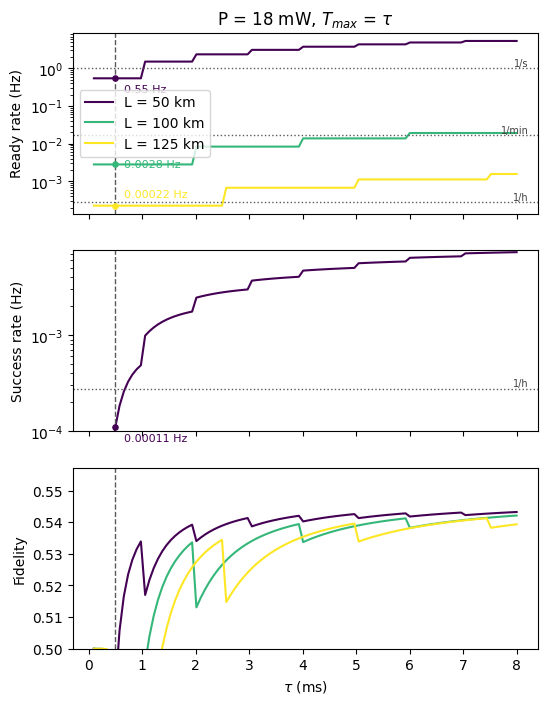

In [11]:
L_scan = [50, 100, 125]
cmap = plt.cm.viridis
norm = plt.Normalize(min(L_scan), max(L_scan))

P_fixed = 18 #P_marker
tau_eff_scan = np.linspace(0.1e-3, 8e-3, 100)
tau_eff_scan_ms = tau_eff_scan * 1e3
tau_eff_marker_ms = 0.5

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(6, 8))

for i, L in enumerate(L_scan):
    color = cmap(norm(L))
    tau_params = params.copy()
    tau_params["L"] = L
    tau_params["P"] = P_fixed

    Gamma_ready_scan = []
    Gamma_succ_scan = []
    F_scan = []

    for tau_eff_now in tau_eff_scan:
        tau_params["tau_eff"] = tau_eff_now
        mylink = DoubleChainLink(tau_params, print_rate=False)
        mylink.get_rates()
        mylink.get_fidelity()
        Gamma_ready_scan.append(mylink.Gamma_ready)
        Gamma_succ_scan.append(mylink.Gamma_succ)
        F_scan.append(mylink.fidelity)

    ready_at_marker = np.interp(tau_eff_marker_ms, tau_eff_scan_ms, Gamma_ready_scan)
    succ_at_marker = np.interp(tau_eff_marker_ms, tau_eff_scan_ms, Gamma_succ_scan)
    fidelity_at_marker = np.interp(tau_eff_marker_ms, tau_eff_scan_ms, F_scan)
    label_offset = 8 * (i - (len(L_scan) - 1) / 2)

    ax1.plot(tau_eff_scan_ms, Gamma_ready_scan, color=color, label=f"L = {L} km")
    ax1.scatter(tau_eff_marker_ms, ready_at_marker, color=color, s=14, zorder=3)
    ax1.annotate(f"{ready_at_marker:.2g} Hz", xy=(tau_eff_marker_ms, ready_at_marker), xytext=(6, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")
    ax1.set_ylabel("Ready rate (Hz)")

    ax2.plot(tau_eff_scan_ms, Gamma_succ_scan, color=color, label=f"L = {L} km")
    ax2.scatter(tau_eff_marker_ms, succ_at_marker, color=color, s=14, zorder=3)
    ax2.annotate(f"{succ_at_marker:.2g} Hz", xy=(tau_eff_marker_ms, succ_at_marker), xytext=(6, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")
    ax2.set_ylabel("Success rate (Hz)")

    ax3.plot(tau_eff_scan_ms, F_scan, color=color)
    ax3.scatter(tau_eff_marker_ms, fidelity_at_marker, color=color, s=14, zorder=3)
    ax3.annotate(f"{fidelity_at_marker:.3f}", xy=(tau_eff_marker_ms, fidelity_at_marker), xytext=(6, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")
    ax3.set_xlabel(r"$\tau$ (ms)")
    ax3.set_ylabel("Fidelity")

ax1.axvline(tau_eff_marker_ms, color="0.35", linestyle="--", linewidth=1)
ax2.axvline(tau_eff_marker_ms, color="0.35", linestyle="--", linewidth=1)
ax3.axvline(tau_eff_marker_ms, color="0.35", linestyle="--", linewidth=1)
ax3.set_ylim(bottom=0.5)
ax2.set_ylim(bottom=1e-4)
ax1.legend()
ax1.set_yscale("log")
ax2.set_yscale("log")
add_rate_reference_lines(ax1)
add_rate_reference_lines(ax2)
ax1.set_title(f"P = {P_fixed:g} mW, $T_{{max}}$ = $\\tau$")
plt.show()

#### Recap with different storage time and different memory modes

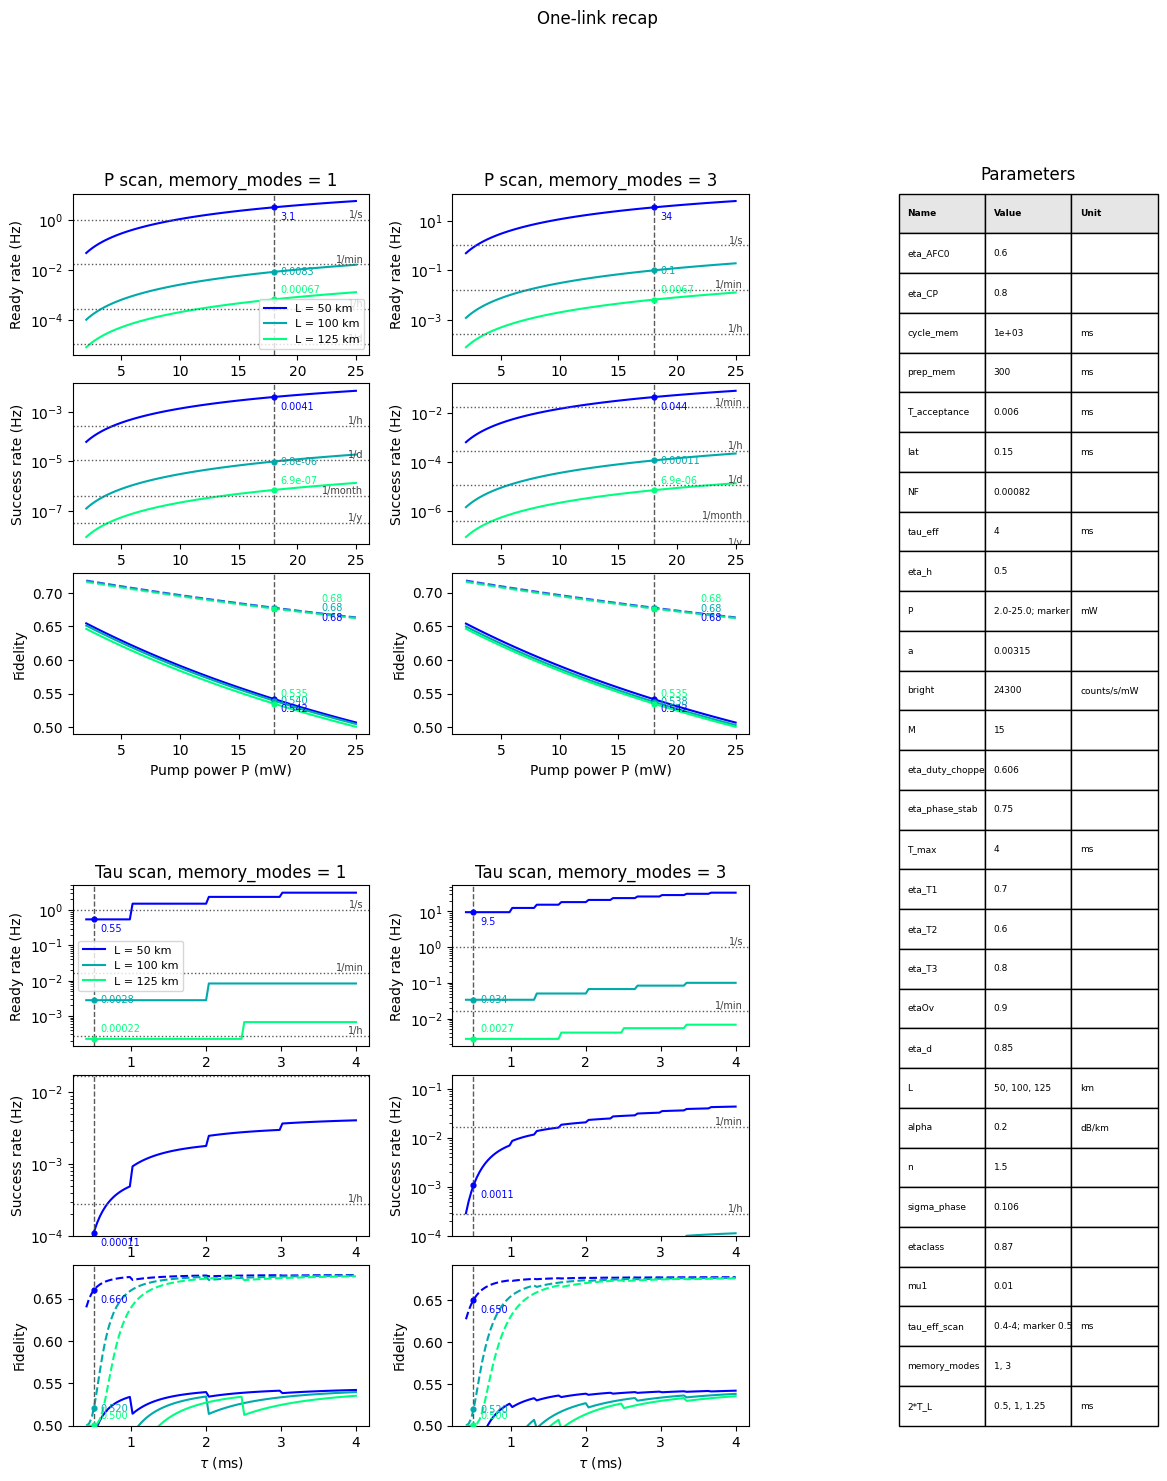

<Figure size 640x480 with 0 Axes>

In [12]:
recap_memory_modes = [1, 3]

L_scan = [50, 100, 125]
cmap = plt.cm.winter
norm = plt.Normalize(min(L_scan), max(L_scan))

P_marker = 18
P_scan = np.linspace(2, 25, 100)
P_fixed = P_marker

tau_eff_scan = np.linspace(0.4e-3, 4e-3, 100)
tau_eff_scan_ms = tau_eff_scan * 1e3
tau_eff_marker_ms = 0.5

fig = plt.figure(figsize=(14, 16))
outer_gs = fig.add_gridspec(2, 2, width_ratios=[2.35, 0.9], height_ratios=[1, 1], wspace=0.32, hspace=0.28)
p_gs = outer_gs[0, 0].subgridspec(3, 2, wspace=0.28, hspace=0.18)
tau_gs = outer_gs[1, 0].subgridspec(3, 2, wspace=0.28, hspace=0.18)

p_axes = [[fig.add_subplot(p_gs[row, col]) for col in range(2)] for row in range(3)]
tau_axes = [[fig.add_subplot(tau_gs[row, col]) for col in range(2)] for row in range(3)]

ax_table = fig.add_subplot(outer_gs[:, 1])
ax_table.axis("off")

for col, memory_modes_now in enumerate(recap_memory_modes):
    for i, L in enumerate(L_scan):
        color = cmap(norm(L))
        Gamma_ready_scan = []
        Gamma_succ_scan = []
        F_scan = []
        F_good_scan = []
        g2_sw_scan = []

        for P_now in P_scan:
            scan_params = params.copy()
            scan_params["L"] = L
            scan_params["P"] = P_now
            mylink = DoubleChainLink(scan_params, memory_modes=memory_modes_now, print_rate=False)
            mylink.get_rates()
            mylink.get_fidelity()
            mylink.get_fidelity_good_sector()
            Gamma_ready_scan.append(mylink.Gamma_ready)
            Gamma_succ_scan.append(mylink.Gamma_succ)
            F_scan.append(mylink.fidelity)
            F_good_scan.append(mylink.fidelity_good_sector)
            g2_sw_scan.append(mylink.g2_sw(0))

        ready_at_marker = np.interp(P_marker, P_scan, Gamma_ready_scan)
        succ_at_marker = np.interp(P_marker, P_scan, Gamma_succ_scan)
        fidelity_at_marker = np.interp(P_marker, P_scan, F_scan)
        fidelity_good_at_marker = np.interp(P_marker, P_scan, F_good_scan)
        g2_sw_at_marker = np.interp(P_marker, P_scan, g2_sw_scan)
        label_offset = 7 * (i - (len(L_scan) - 1) / 2)

        p_axes[0][col].plot(P_scan, Gamma_ready_scan, color=color, label=f"L = {L} km")
        p_axes[0][col].scatter(P_marker, ready_at_marker, color=color, s=12, zorder=3)
        p_axes[0][col].annotate(f"{ready_at_marker:.2g}", xy=(P_marker, ready_at_marker), xytext=(5, label_offset), textcoords="offset points", color=color, fontsize=7, va="center")

        p_axes[1][col].plot(P_scan, Gamma_succ_scan, color=color, label=f"L = {L} km")
        p_axes[1][col].scatter(P_marker, succ_at_marker, color=color, s=12, zorder=3)
        p_axes[1][col].annotate(f"{succ_at_marker:.2g}", xy=(P_marker, succ_at_marker), xytext=(5, label_offset), textcoords="offset points", color=color, fontsize=7, va="center")

        p_axes[2][col].plot(P_scan, F_scan, color=color)
        p_axes[2][col].plot(P_scan, F_good_scan, color=color, linestyle="--", alpha=0.75)
        p_axes[2][col].scatter(P_marker, fidelity_at_marker, color=color, s=12, zorder=3)
        p_axes[2][col].scatter(P_marker, fidelity_good_at_marker, color=color, s=12, marker="s", zorder=3)
        p_axes[2][col].annotate(f"{fidelity_at_marker:.3f}", xy=(P_marker, fidelity_at_marker), xytext=(5, label_offset), textcoords="offset points", color=color, fontsize=7, va="center")
        p_axes[2][col].annotate(f"{fidelity_good_at_marker:.2f}", xy=(P_marker, fidelity_good_at_marker), xytext=(34, label_offset), textcoords="offset points", color=color, fontsize=7, va="center")

for col, memory_modes_now in enumerate(recap_memory_modes):
    for i, L in enumerate(L_scan):
        color = cmap(norm(L))
        Gamma_ready_scan = []
        Gamma_succ_scan = []
        F_scan = []
        F_good_scan = []

        for tau_eff_now in tau_eff_scan:
            tau_params = params.copy()
            tau_params["L"] = L
            tau_params["P"] = P_fixed
            tau_params["tau_eff"] = tau_eff_now
            mylink = DoubleChainLink(tau_params, memory_modes=memory_modes_now, print_rate=False)
            mylink.get_rates()
            mylink.get_fidelity()
            mylink.get_fidelity_good_sector()
            Gamma_ready_scan.append(mylink.Gamma_ready)
            Gamma_succ_scan.append(mylink.Gamma_succ)
            F_scan.append(mylink.fidelity)
            F_good_scan.append(mylink.fidelity_good_sector)
        ready_at_marker = np.interp(tau_eff_marker_ms, tau_eff_scan_ms, Gamma_ready_scan)
        succ_at_marker = np.interp(tau_eff_marker_ms, tau_eff_scan_ms, Gamma_succ_scan)
        fidelity_at_marker = np.interp(tau_eff_marker_ms, tau_eff_scan_ms, F_scan)
        fidelity_good_at_marker = np.interp(tau_eff_marker_ms, tau_eff_scan_ms, F_good_scan)
        label_offset = 7 * (i - (len(L_scan) - 1) / 2)

        tau_axes[0][col].plot(tau_eff_scan_ms, Gamma_ready_scan, color=color, label=f"L = {L} km")
        tau_axes[0][col].scatter(tau_eff_marker_ms, ready_at_marker, color=color, s=12, zorder=3)
        tau_axes[0][col].annotate(f"{ready_at_marker:.2g}", xy=(tau_eff_marker_ms, ready_at_marker), xytext=(5, label_offset), textcoords="offset points", color=color, fontsize=7, va="center")

        tau_axes[1][col].plot(tau_eff_scan_ms, Gamma_succ_scan, color=color, label=f"L = {L} km")
        tau_axes[1][col].scatter(tau_eff_marker_ms, succ_at_marker, color=color, s=12, zorder=3)
        tau_axes[1][col].annotate(f"{succ_at_marker:.2g}", xy=(tau_eff_marker_ms, succ_at_marker), xytext=(5, label_offset), textcoords="offset points", color=color, fontsize=7, va="center")

        tau_axes[2][col].plot(tau_eff_scan_ms, F_scan, color=color)
        tau_axes[2][col].scatter(tau_eff_marker_ms, fidelity_at_marker, color=color, s=12, zorder=3)
        tau_axes[2][col].annotate(f"{fidelity_at_marker:.3f}", xy=(tau_eff_marker_ms, fidelity_at_marker), xytext=(5, label_offset), textcoords="offset points", color=color, fontsize=7, va="center")
        

        tau_axes[2][col].plot(tau_eff_scan_ms, F_good_scan, color=color, linestyle="--")
        tau_axes[2][col].scatter(tau_eff_marker_ms, fidelity_good_at_marker, color=color, s=12, zorder=3)
        tau_axes[2][col].annotate(f"{fidelity_good_at_marker:.3f}", xy=(tau_eff_marker_ms, fidelity_good_at_marker), xytext=(5, label_offset), textcoords="offset points", color=color, fontsize=7, va="center")
        tau_axes[2][col].set_ylim(bottom=0.5)
        
for col, memory_modes_now in enumerate(recap_memory_modes):
    p_axes[0][col].set_title(f"P scan, memory_modes = {memory_modes_now}")
    tau_axes[0][col].set_title(f"Tau scan, memory_modes = {memory_modes_now}")
    p_axes[2][col].set_xlabel("Pump power P (mW)")
    tau_axes[2][col].set_xlabel(r"$\tau$ (ms)")
    p_axes[0][col].set_yscale("log")
    p_axes[1][col].set_yscale("log")
    tau_axes[0][col].set_yscale("log")
    tau_axes[1][col].set_yscale("log")
    tau_axes[1][col].set_ylim(bottom=1e-4)
    add_rate_reference_lines(p_axes[0][col])
    add_rate_reference_lines(p_axes[1][col])
    add_rate_reference_lines(tau_axes[0][col])
    add_rate_reference_lines(tau_axes[1][col])
    for row in range(3):
        p_axes[row][col].axvline(P_marker, color="0.35", linestyle="--", linewidth=1)
        tau_axes[row][col].axvline(tau_eff_marker_ms, color="0.35", linestyle="--", linewidth=1)

for axes_group in (p_axes, tau_axes):
    for col in range(2):
        axes_group[0][col].set_ylabel("Ready rate (Hz)")
        axes_group[1][col].set_ylabel("Success rate (Hz)")
        axes_group[2][col].set_ylabel("Fidelity")

p_axes[0][0].legend(fontsize=8)
tau_axes[0][0].legend(fontsize=8)

table_params = params.copy()
table_params["P"] = f"{P_scan[0]:.1f}-{P_scan[-1]:.1f}; marker {P_marker:g}"
table_params["tau_eff_scan"] = f"{tau_eff_scan_ms[0]:.3g}-{tau_eff_scan_ms[-1]:.3g}; marker {tau_eff_marker_ms:g}"
table_params["L"] = ", ".join(str(L) for L in L_scan)
table_params["memory_modes"] = ", ".join(str(memory_modes) for memory_modes in recap_memory_modes)
table_params["2*T_L"] = ", ".join(f"{2 * L * params['n'] / params['c'] * 1e3:.3g}" for L in L_scan)
table_params.pop("c", None)

time_params = {"cycle_mem", "prep_mem", "T_acceptance", "lat", "tau_eff", "T_max", "T_L"}
param_units = {
    "cycle_mem": "ms",
    "prep_mem": "ms",
    "T_acceptance": "ms",
    "lat": "ms",
    "tau_eff": "ms",
    "tau_eff_scan": "ms",
    "T_max": "ms",
    "P": "mW",
    "bright": "counts/s/mW",
    "L": "km",
    "alpha": "dB/km",
    "n": "",
    "2*T_L": "ms",
    "memory_modes": "",
}
table_rows = []
for name, value in table_params.items():
    if name in time_params and isinstance(value, (int, float)):
        value = f"{value * 1e3:.3g}"
    elif isinstance(value, float):
        value = f"{value:.3g}"
    table_rows.append([name, value, param_units.get(name, "")])

param_table = ax_table.table(
    cellText=table_rows,
    colLabels=["Name", "Value", "Unit"],
    cellLoc="left",
    colLoc="left",
    loc="center",
    bbox=[0, 0, 1, 1],
)
param_table.auto_set_font_size(False)
param_table.set_fontsize(6.5)
param_table.scale(1, 1.1)
for (row, col), cell in param_table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("0.9")
ax_table.set_title("Parameters", pad=10)

fig.suptitle("One-link recap", y=0.995)
plt.show()
plt.tight_layout()

#### Fidelity rate threshold

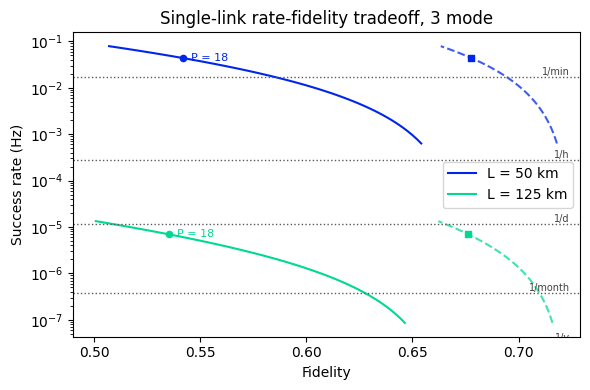

In [13]:
P_scan = np.linspace(2, 25, 100)
L_scan = [50, 125]
P_marker = 18
memory_modes_to_plot = 3
colors = plt.cm.winter(np.linspace(0.15, 0.85, len(L_scan)))

fig, ax = plt.subplots(figsize=(6, 4))

for color, L_now in zip(colors, L_scan):
    success_scan = []
    F_scan = []
    F_good_scan = []

    for P_now in P_scan:
        scan_params = params.copy()
        scan_params["P"] = P_now
        scan_params["L"] = L_now

        mylink = DoubleChainLink(scan_params, memory_modes=memory_modes_to_plot, print_rate=False)
        mylink.get_rates()
        mylink.get_fidelity()
        mylink.get_fidelity_good_sector()

        success_scan.append(mylink.Gamma_succ)
        F_scan.append(mylink.fidelity)
        F_good_scan.append(mylink.fidelity_good_sector)

    success_at_marker = np.interp(P_marker, P_scan, success_scan)
    fidelity_at_marker = np.interp(P_marker, P_scan, F_scan)
    fidelity_good_at_marker = np.interp(P_marker, P_scan, F_good_scan)

    ax.plot(F_scan, success_scan, color=color, label=f"L = {L_now} km")
    ax.plot(F_good_scan, success_scan, color=color, linestyle="--", alpha=0.75)
    ax.scatter(fidelity_at_marker, success_at_marker, color=color, s=20, zorder=3)
    ax.scatter(fidelity_good_at_marker, success_at_marker, color=color, s=20, marker="s", zorder=3)
    ax.annotate(
        f"P = {P_marker:g}",
        xy=(fidelity_at_marker, success_at_marker),
        xytext=(6, 0),
        textcoords="offset points",
        color=color,
        fontsize=8,
        va="center",
    )
ax.set_xlabel("Fidelity")
ax.set_ylabel("Success rate (Hz)")
ax.set_yscale("log")
add_rate_reference_lines(ax)
ax.legend()
ax.set_title(f"Single-link rate-fidelity tradeoff, {memory_modes_to_plot} mode")
plt.tight_layout()
plt.show()


#### Fidelity dependence on the phase distribution

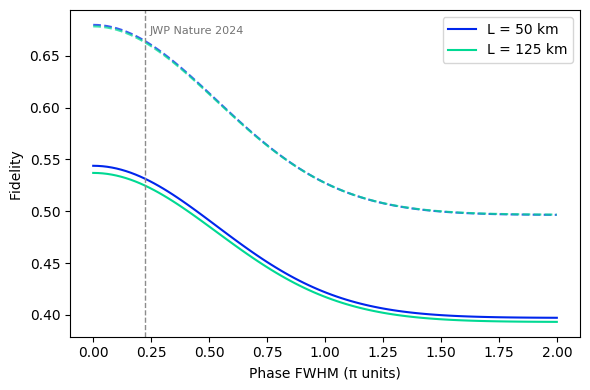

In [14]:
phase_fwhm_scan = np.linspace(0, 2 * np.pi, 100)
L_scan = [50, 125]
P_fixed = 18
memory_modes_phase_scan = 1
jwp_phase_fwhm = 2.355 * np.deg2rad(17)
jwp_phase_fwhm_pi = jwp_phase_fwhm / np.pi

colors = plt.cm.winter(np.linspace(0.15, 0.85, len(L_scan)))

fig, ax = plt.subplots(figsize=(6, 4))

for color, L_now in zip(colors, L_scan):
    F_scan = []
    F_good_scan = []
    for phase_fwhm_now in phase_fwhm_scan:
        scan_params = params.copy()
        scan_params["P"] = P_fixed
        scan_params["L"] = L_now
        scan_params["sigma_phase"] = phase_fwhm_now / 2.355

        mylink = DoubleChainLink(scan_params, memory_modes=memory_modes_phase_scan, print_rate=False)
        mylink.get_rates()
        mylink.get_fidelity()
        mylink.get_fidelity_good_sector()
        F_scan.append(mylink.fidelity)
        F_good_scan.append(mylink.fidelity_good_sector)

    ax.plot(phase_fwhm_scan / np.pi, F_scan, color=color, label=f"L = {L_now} km")
    ax.plot(phase_fwhm_scan / np.pi, F_good_scan, color=color, linestyle="--", alpha=0.75)

ax.axvline(jwp_phase_fwhm_pi, color="0.55", linestyle="--", linewidth=1)
ax.text(jwp_phase_fwhm_pi + 0.02, 0.95, "JWP Nature 2024", transform=ax.get_xaxis_transform(), color="0.45", fontsize=8, ha="left", va="top")
ax.set_xlabel("Phase FWHM (π units)")
ax.set_ylabel("Fidelity ")
ax.legend()
plt.tight_layout()
plt.show()


#### Comparing the single mode regime with larger T_acceptance and the multimode regime

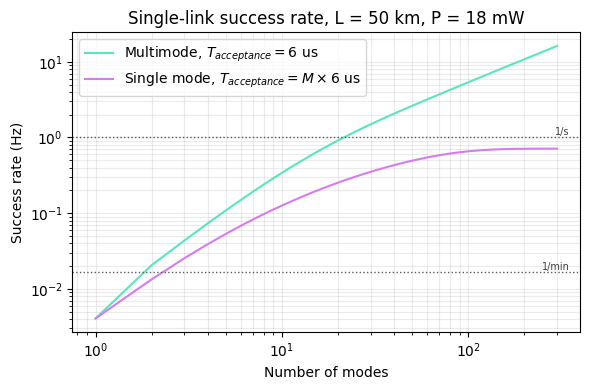

In [15]:
base_T_acceptance = params["T_acceptance"]
mode_scan = np.arange(1, 300)
color1 = "#5ae6bc"
color2 = "#d57cf0"
comparison_params = params.copy()
comparison_params["T_acceptance"] = base_T_acceptance
comparison_params["L"] = 50
comparison_params["P"] = 18

multimode_success = []
single_mode_large_acceptance_success = []

for mode_count in mode_scan:
    multimode_params = comparison_params.copy()
    multimode_params["T_acceptance"] = base_T_acceptance
    multimode_link = DoubleChainLink(multimode_params, memory_modes=int(mode_count), print_rate=False)
    multimode_link.get_rates()
    multimode_success.append(multimode_link.Gamma_succ)

    single_mode_params = comparison_params.copy()
    single_mode_params["T_acceptance"] = mode_count * base_T_acceptance
    single_mode_link = DoubleChainLink(single_mode_params, memory_modes=1, print_rate=False)
    single_mode_link.get_rates()
    single_mode_large_acceptance_success.append(single_mode_link.Gamma_succ)

multimode_success = np.asarray(multimode_success)
single_mode_large_acceptance_success = np.asarray(single_mode_large_acceptance_success)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(
    mode_scan,
    multimode_success,
    color=color1,
    markersize=3,
    label=fr"Multimode, $T_{{acceptance}} = {base_T_acceptance * 1e6:g}$ us",
)
ax.plot(
    mode_scan,
    single_mode_large_acceptance_success,
    markersize=3,
    color=color2,
    label=fr"Single mode, $T_{{acceptance}} = M \times {base_T_acceptance * 1e6:g}$ us",
)

ax.set_xlabel("Number of modes")
ax.set_ylabel("Success rate (Hz)")
ax.set_yscale("log")
ax.set_xscale("log")
add_rate_reference_lines(ax)
ax.grid(True, which="both", alpha=0.25)
ax.legend()
ax.set_title(
    f"Single-link success rate, L = {comparison_params['L']:g} km, "
    f"P = {comparison_params['P']:g} mW"
)
plt.tight_layout()
plt.show()


## Two links

#### Double link made of double chain class

In [16]:
class DoubleChainDoubleLink:
    def __init__(self, params, memory_modes=1, print_rate=False):
        self.params = SimpleNamespace(**params)
        self.calculate_params()
        self.memory_modes = memory_modes
        self.print_rate = print_rate

    def calculate_params(self):
        """Calculate parameters that depend on other parameters."""
        self.params.L = self.params.L / 2
        self.params.eta_m0 = self.params.eta_AFC0 * self.params.eta_CP**2
        self.params.eta_duty_mem = 1 - self.params.prep_mem / self.params.cycle_mem
        self.params.R0 = self.params.bright / self.params.M
        self.params.g2 = 1 + 1 / (self.params.a * self.params.P)
        self.params.T_max = self.params.tau_eff * 0.5
        self.params.eta_path = self.params.eta_T1 * self.params.eta_T2 * self.params.eta_T3
        self.params.fib = 10 ** (-self.params.alpha * self.params.L / 10)
        self.params.T_L = self.params.L * self.params.n / self.params.c
        self.params.eta_BSM = 0.5
        self.params.I_HOM = self.params.etaOv
        self.params.NF = self.params.mu1 * self.params.eta_T2 * self.params.eta_T3 * self.params.eta_d * self.params.eta_m0
    
    def eta_m(self, t):
        storage_time = 2 * self.params.T_L + t
        return self.params.eta_m0 * np.exp(-storage_time**2 / self.params.tau_eff**2)

    def g2_sw(self,t):
        # from swappinger PRX
        return self.params.g2 * (self.params.eta_h * self.eta_m(t) * self.params.eta_T2 * self.params.eta_T3 * self.params.eta_d / self.params.NF + 1) / (self.params.g2 + self.params.eta_h * self.eta_m(t) * self.params.eta_T2 * self.params.eta_T3 * self.params.eta_d / self.params.NF)

    def Vcal(self, t):
        """Visibility as a function of storage time."""
        return (self.g2_sw(t) - 1) / (self.g2_sw(t) + 1) * np.exp(- (self.params.sigma_phase**2) /2 ) * self.params.etaOv **2  * self.params.etaclass

    def p10(self, t):
        """Probability to detect a photon on the left of one elementary link, and no photon on the right, conditioned on idler detection."""
        return self.eta_m(t) * self.params.eta_path * self.params.eta_d * self.params.eta_h / 2 + self.params.NF

    def p01(self, t):
        return self.p10(t)

    def p11(self, t):
        """Probability to detect a photon on both sides of one elementary link, conditioned on idler detection."""
        return 4 * self.p10(t) * self.p10(t) * (self.g2_sw(t) - 1) / (self.g2_sw(t) * self.g2_sw(t))

    def p00(self, t):
        return np.maximum(1 - self.p01(t) - self.p10(t) - self.p11(t), 0)

    def detected_single_weight(self, t):
        return self.p01(t) + self.p10(t)

    def D_link(self, t_a, t_b):
        """Accepted double-chain readout weight, including useful and bad accepted sectors."""
        useful = self.detected_single_weight(t_a) * self.detected_single_weight(t_b)
        bad = self.p11(t_a) * self.p00(t_b) + self.p00(t_a) * self.p11(t_b)
        return useful + 2 * bad

    def chi(self, t):
        return (2 * self.p10(t))/(2 * self.p10(t) + self.p11(t))

    def W_k_(self, k):
        return self.p_h**2 if k == 0 else 2 * self.p_h**2 * self.p_no_h**k

    def W_rdy_j_(self, j):
        return sum(self.W_k_(k) for k in range(int(self.N) - j + 1))

    def R_j_(self, j):
        return sum(self.W_k_(k) * self.eta_m(j*self.Delta) * self.eta_m((j+k)*self.Delta) for k in range(int(self.N) - j + 1))

    def S_j_(self, j):
        return sum(self.W_k_(k) * self.eta_m(j*self.Delta) * self.eta_m((j+k)*self.Delta) * self.chi(j*self.Delta) * self.chi((j+k)*self.Delta) for k in range(int(self.N) - j + 1))

    def C_j_(self, j):
        return sum(self.W_k_(k) * self.eta_m(j*self.Delta) * self.eta_m((j+k)*self.Delta) * self.chi(j*self.Delta) * self.chi((j+k)*self.Delta) * self.Vcal(j*self.Delta) * self.Vcal((j+k)*self.Delta) for k in range(int(self.N) - j + 1))

    def R_link_j_(self, j):
        return sum(self.W_k_(k) * self.D_link(j*self.Delta, (j+k)*self.Delta) for k in range(int(self.N) - j + 1))

    def S_link_j_(self, j):
        return sum(self.W_k_(k) * self.detected_single_weight(j*self.Delta) * self.detected_single_weight((j+k)*self.Delta) for k in range(int(self.N) - j + 1))

    def C_link_j_(self, j):
        return sum(self.W_k_(k) * self.detected_single_weight(j*self.Delta) * self.detected_single_weight((j+k)*self.Delta) * self.Vcal(j*self.Delta) * self.Vcal((j+k)*self.Delta) for k in range(int(self.N) - j + 1))

    def get_rates(self):
        self.Delta = 2 * self.params.T_L
        self.N = int(np.floor(self.params.T_max / self.Delta))
        self.Gamma_ch = self.params.R0 * self.params.P * self.params.fib * self.params.eta_d * 2
        self.p_h = 1 - np.exp(- self.Gamma_ch * self.params.T_acceptance)
        self.p_no_h = 1 - self.p_h
        self.duty = self.params.eta_duty_mem * self.params.eta_duty_chopper * self.params.eta_phase_stab

        if self.memory_modes == 1:
            self.W_rdy_1L = self.p_h**2 + 2*self.p_h*self.p_no_h*(1 - self.p_no_h**self.N)
            self.P_rdy_given_nevt_1L = self.W_rdy_1L / (1 - self.p_no_h**2)
            self.Gamma_rdy_1L_raw = self.W_rdy_1L / (1 + 2*self.p_no_h*(1 - self.p_no_h**self.N)) / self.Delta

            self.rho = min(self.Gamma_rdy_1L_raw * self.Delta, 1)
            self.Q = 1 - self.rho
            self.A = 0 if self.W_rdy_1L == 0 else (self.p_h**2 * (1 - self.Q**self.N) + sum(2*self.p_h**2*self.p_no_h**k * (1 - self.Q**(self.N-k)) for k in range(1, self.N + 1))) / self.W_rdy_1L

            self.P_rdy_given_nevt_2L = (self.rho**2 + 2*self.rho*self.Q*self.A) / (1 - self.Q**2)
            self.n_cycle_2L = (1 + 2*self.Q*self.A) / (1 - self.Q**2)
            self.T_cycle_2L = self.n_cycle_2L * self.Delta + self.P_rdy_given_nevt_2L*self.params.lat
            self.Gamma_rdy_2L = self.P_rdy_given_nevt_2L / self.T_cycle_2L * self.duty

            self.R_sync_den = self.W_rdy_j_(0)**2 + 2*sum(self.Q**j * self.W_rdy_j_(j) * self.W_rdy_j_(0) for j in range(1, self.N + 1))
            self.R_sync_num = self.R_j_(0)**2 + 2*sum(self.Q**j * self.R_j_(j) * self.R_j_(0) for j in range(1, self.N + 1))
            self.eta_avg = np.nan if self.R_sync_den == 0 else self.R_sync_num / self.R_sync_den
            self.C2 = self.params.eta_BSM * self.params.eta_h**4 * self.params.eta_path**4 * self.params.eta_d**4 / 4
            self.P_succ_given_rdy_2L = self.C2 * self.eta_avg
            self.Gamma_2L = self.Gamma_rdy_2L * self.P_succ_given_rdy_2L
        else:
            self.age_step = self.Delta / self.memory_modes
            self.N_M = max(1, int(np.ceil(self.params.T_max / self.age_step)))
            self.lambda_M = self.memory_modes * self.p_h / self.Delta
            self.Gamma_rdy_2L_M = 4 * self.lambda_M * (1 - self.p_no_h**self.N_M)**3 * self.duty

            self.P_nonempty_M = 1 - self.p_no_h**self.N_M
            self.eta_stored_M = sum(self.p_h * self.p_no_h**j * self.eta_m(j * self.age_step) for j in range(self.N_M)) / self.P_nonempty_M
            self.eta_avg = self.eta_m(0) * self.eta_stored_M**3
            self.C2 = self.params.eta_BSM * self.params.eta_h**4 * self.params.eta_path**4 * self.params.eta_d**4 / 4
            self.P_succ_given_rdy_2L_M = self.C2 * self.eta_avg
            self.Gamma_2L_M = self.Gamma_rdy_2L_M * self.P_succ_given_rdy_2L_M

        if self.print_rate:
            if self.memory_modes == 1:
                print(f"Ready rate: {self.Gamma_rdy_2L:.2f} Hz")
                print(f"Success rate: {self.Gamma_2L:.4e} Hz")
                print(f"Number of rounds before giving up: {int(self.N)}")
            else:
                print(f"Ready rate: {self.Gamma_rdy_2L_M:.2f} Hz")
                print(f"Success rate: {self.Gamma_2L_M:.4e} Hz")
                print(f"Number of modes before giving up: {int(self.N_M)}")

    def get_fidelity(self):
        if self.memory_modes == 1 and not hasattr(self, "Gamma_2L"):
            self.get_rates()
        if self.memory_modes != 1 and not hasattr(self, "Gamma_2L_M"):
            self.get_rates()

        if self.memory_modes == 1:
            R0 = self.R_link_j_(0)
            S0 = self.S_link_j_(0)
            C0 = self.C_link_j_(0)

            num = S0**2 + C0**2 + 2*sum(self.Q**j * (self.S_link_j_(j)*S0 + self.C_link_j_(j)*C0) for j in range(1, self.N + 1))
            den = R0**2 + 2*sum(self.Q**j * self.R_link_j_(j)*R0 for j in range(1, self.N + 1))
            self.Fbar_2L_disc = np.nan if den == 0 else num / (2 * den)
        else:
            idx = np.arange(self.N_M)
            weights = self.p_h * self.p_no_h**idx
            ages = idx * self.age_step

            detected_single = self.detected_single_weight(ages)
            visibility = self.Vcal(ages)
            p11 = self.p11(ages)
            p00 = self.p00(ages)

            detected_single_0 = self.detected_single_weight(0)
            visibility_0 = self.Vcal(0)
            p11_0 = self.p11(0)
            p00_0 = self.p00(0)

            sum_s = np.sum(weights * detected_single)
            sum_s_v = np.sum(weights * detected_single * visibility)
            sum_p11 = np.sum(weights * p11)
            sum_p00 = np.sum(weights * p00)

            R_fresh = detected_single_0 * sum_s + 2 * (p11_0 * sum_p00 + p00_0 * sum_p11)
            S_fresh = detected_single_0 * sum_s
            C_fresh = detected_single_0 * visibility_0 * sum_s_v

            R_stored = sum_s**2 + 4 * sum_p11 * sum_p00
            S_stored = sum_s**2
            C_stored = sum_s_v**2

            den = R_fresh * R_stored
            num = S_fresh * S_stored + C_fresh * C_stored
            self.Fbar_2L_M = np.nan if den == 0 else num / (2 * den)

        if self.print_rate:
            if self.memory_modes == 1:
                print(f"Fidelity: {self.Fbar_2L_disc:.4f}")
            else:
                print(f"Fidelity: {self.Fbar_2L_M:.4f}")

    def get_fidelity_good_sector(self):
        """Fidelity conditioned on the useful single-excitation sector only."""
        if self.memory_modes == 1 and not hasattr(self, "Gamma_2L"):
            self.get_rates()
        if self.memory_modes != 1 and not hasattr(self, "Gamma_2L_M"):
            self.get_rates()

        if self.memory_modes == 1:
            R0 = self.R_j_(0)
            S0 = self.S_j_(0)
            C0 = self.C_j_(0)

            num = S0**2 + C0**2 + 2*sum(self.Q**j * (self.S_j_(j)*S0 + self.C_j_(j)*C0) for j in range(1, self.N + 1))
            den = R0**2 + 2*sum(self.Q**j * self.R_j_(j)*R0 for j in range(1, self.N + 1))
            self.Fbar_2L_good_sector_disc = np.nan if den == 0 else num / (2 * den)
            self.fidelity_good_sector = self.Fbar_2L_good_sector_disc
        else:
            B0 = sum(self.p_h * self.p_no_h**j * self.eta_m(j * self.age_step) for j in range(self.N_M))
            Bq = sum(self.p_h * self.p_no_h**j * self.eta_m(j * self.age_step) * self.chi(j * self.age_step) for j in range(self.N_M))
            BqV = sum(self.p_h * self.p_no_h**j * self.eta_m(j * self.age_step) * self.chi(j * self.age_step) * self.Vcal(j * self.age_step) for j in range(self.N_M))
            self.Fbar_2L_good_sector_M = np.nan if B0 == 0 else self.chi(0) / 2 * (Bq**3 + self.Vcal(0)*BqV**3) / B0**3
            self.fidelity_good_sector = self.Fbar_2L_good_sector_M

        if self.print_rate:
            print(f"Good-sector fidelity: {self.fidelity_good_sector:.4f}")


In [17]:
my_doublelink = DoubleChainDoubleLink(params, print_rate=True)
my_doublelink.get_rates()
my_doublelink.get_fidelity()


Ready rate: 15.52 Hz
Success rate: 1.3182e-05 Hz
Number of rounds before giving up: 7
Fidelity: 0.3577


#### Double link with different modes

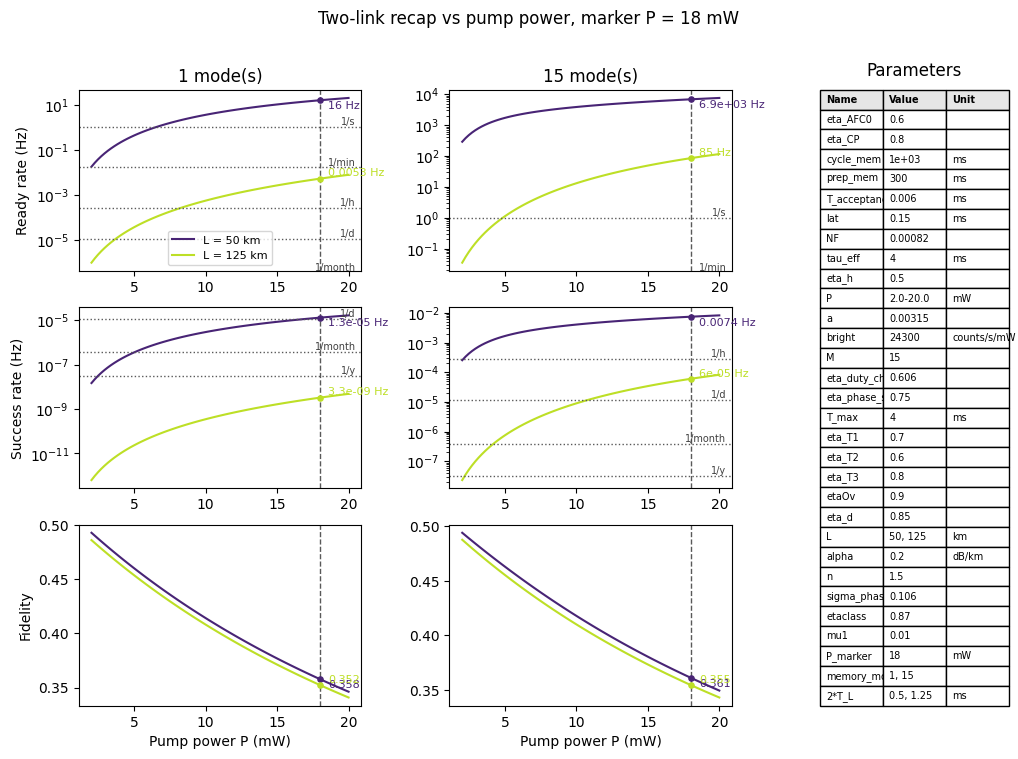

In [18]:
double_recap_memory_modes = [1, 15]
P_scan = np.linspace(2, 20, 80)
L_scan = [50, 125]
P_marker = 18

table_params = params.copy()
table_params["P"] = f"{P_scan[0]:.1f}-{P_scan[-1]:.1f}"
table_params["P_marker"] = f"{P_marker:.3g}"
table_params["L"] = ", ".join(str(L) for L in L_scan)
table_params["memory_modes"] = ", ".join(str(m) for m in double_recap_memory_modes)
table_params["2*T_L"] = ", ".join(f"{2 * L * params['n'] / params['c'] * 1e3:.3g}" for L in L_scan)
table_params.pop("c", None)
time_params = {"cycle_mem", "prep_mem", "T_acceptance", "lat", "tau_eff", "T_max", "T_L"}
param_units = {
    "cycle_mem": "ms",
    "prep_mem": "ms",
    "T_acceptance": "ms",
    "lat": "ms",
    "tau_eff": "ms",
    "P": "mW",
    "P_marker": "mW",
    "bright": "counts/s/mW",
    "Rid0": "Hz/mW",
    "T_max": "ms",
    "L": "km",
    "alpha": "dB/km",
    "T_L": "ms",
    "2*T_L": "ms",
}
table_rows = []
for name, value in table_params.items():
    if name in time_params and isinstance(value, (int, float)):
        value = f"{value * 1e3:.3g}"
    elif isinstance(value, float):
        value = f"{value:.3g}"
    table_rows.append([name, value, param_units.get(name, "")])

fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(3, len(double_recap_memory_modes) + 1, width_ratios=[3] * len(double_recap_memory_modes) + [2], wspace=0.35)
axes = np.array([[fig.add_subplot(gs[row, col]) for col in range(len(double_recap_memory_modes))] for row in range(3)])
ax_table = fig.add_subplot(gs[:, -1])
ax_table.axis("off")
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(L_scan)))

for col, memory_modes_now in enumerate(double_recap_memory_modes):
    for i, L_now in enumerate(L_scan):
        ready_scan = []
        success_scan = []
        F_scan = []
        for P_now in P_scan:
            scan_params = params.copy()
            scan_params["P"] = P_now
            scan_params["L"] = L_now
            mylink = DoubleChainDoubleLink(scan_params, memory_modes=memory_modes_now, print_rate=False)
            mylink.get_rates()
            mylink.get_fidelity()
            if memory_modes_now == 1:
                ready_scan.append(mylink.Gamma_rdy_2L)
                success_scan.append(mylink.Gamma_2L)
                F_scan.append(mylink.Fbar_2L_disc)
            else:
                ready_scan.append(mylink.Gamma_rdy_2L_M)
                success_scan.append(mylink.Gamma_2L_M)
                F_scan.append(mylink.Fbar_2L_M)

        color = colors[i]
        ready_at_marker = np.interp(P_marker, P_scan, ready_scan)
        succ_at_marker = np.interp(P_marker, P_scan, success_scan)
        fidelity_at_marker = np.interp(P_marker, P_scan, F_scan)
        label_offset = 8 * (i - (len(L_scan) - 1) / 2)

        axes[0][col].plot(P_scan, ready_scan, color=color, label=f"L = {L_now} km")
        axes[0][col].scatter(P_marker, ready_at_marker, color=color, s=14, zorder=3)
        axes[0][col].annotate(f"{ready_at_marker:.2g} Hz", xy=(P_marker, ready_at_marker), xytext=(6, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")

        axes[1][col].plot(P_scan, success_scan, color=color)
        axes[1][col].scatter(P_marker, succ_at_marker, color=color, s=14, zorder=3)
        axes[1][col].annotate(f"{succ_at_marker:.2g} Hz", xy=(P_marker, succ_at_marker), xytext=(6, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")

        axes[2][col].plot(P_scan, F_scan, color=color)
        axes[2][col].scatter(P_marker, fidelity_at_marker, color=color, s=14, zorder=3)
        axes[2][col].annotate(f"{fidelity_at_marker:.3f}", xy=(P_marker, fidelity_at_marker), xytext=(6, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")

    axes[0][col].set_title(f"{memory_modes_now} mode(s)")
    axes[0][col].set_yscale("log")
    axes[1][col].set_yscale("log")
    add_rate_reference_lines(axes[0][col])
    add_rate_reference_lines(axes[1][col])
    axes[2][col].set_xlabel("Pump power P (mW)")
    for row in range(3):
        axes[row][col].axvline(P_marker, color="0.35", linestyle="--", linewidth=1)

axes[0][0].set_ylabel("Ready rate (Hz)")
axes[1][0].set_ylabel("Success rate (Hz)")
axes[2][0].set_ylabel("Fidelity")
axes[0][0].legend(fontsize=8)

param_table = ax_table.table(
    cellText=table_rows,
    colLabels=["Name", "Value", "Unit"],
    cellLoc="left",
    colLoc="left",
    loc="center",
    bbox=[0, 0, 1, 1],
)
param_table.auto_set_font_size(False)
param_table.set_fontsize(7)
param_table.scale(1, 1.15)
for (row, col), cell in param_table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("0.9")
ax_table.set_title("Parameters", pad=10)
fig.suptitle(f"Two-link recap vs pump power, marker P = {P_marker:g} mW")
plt.show()


## Comparison one link two link for the double chain

#### Varying pump power, 1 mode or 15 modes

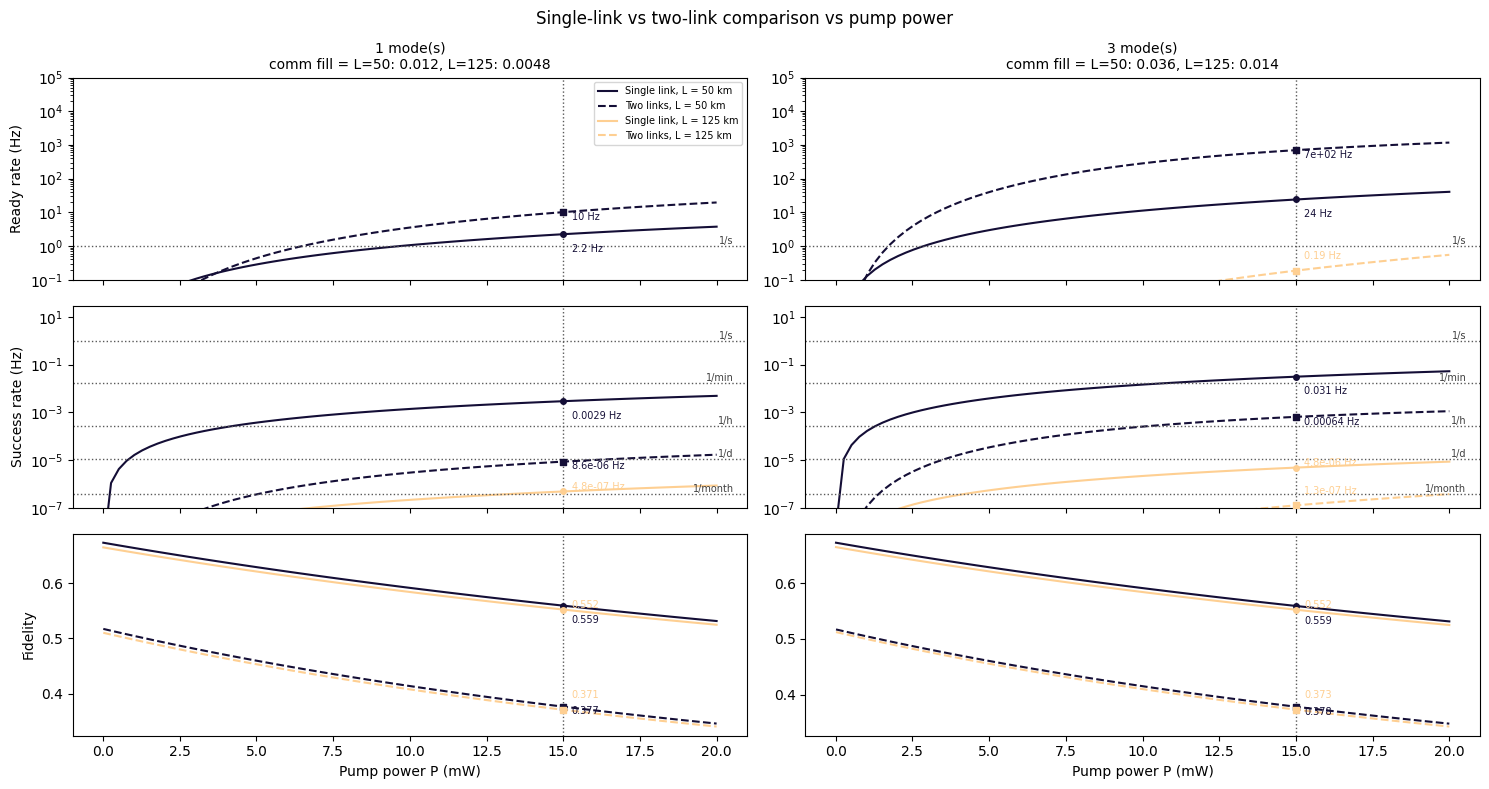

In [19]:
comparison_memory_modes = [1, 3]
L_scan = [50, 125]
P_scan = np.linspace(0.01, 20, 80)
P_marker = 15

single_link_colors = plt.cm.magma(np.linspace(0.1, 0.9, len(L_scan)))
two_link_colors = plt.cm.magma(np.linspace(0.1, 0.9, len(L_scan)))
case_specs = [
    ("Single link", DoubleChainLink, "-", single_link_colors, "o"),
    ("Two links", DoubleChainDoubleLink, "--", two_link_colors, "s"),
]

fig, axes = plt.subplots(3, len(comparison_memory_modes), figsize=(15, 8), sharex="col")

for col, memory_modes_now in enumerate(comparison_memory_modes):
    fill_fractions = []
    for L_now in L_scan:
        two_way_time = 2 * L_now * params["n"] / params["c"]
        fill_fractions.append(memory_modes_now * params["T_acceptance"] / two_way_time)

    for i, L_now in enumerate(L_scan):
        for case_idx, (case_label, link_cls, linestyle, case_colors, marker) in enumerate(case_specs):
            color = case_colors[i]
            ready_scan = []
            success_scan = []
            F_scan = []

            for P_now in P_scan:
                scan_params = params.copy()
                scan_params["P"] = P_now
                scan_params["L"] = L_now
                mylink = link_cls(scan_params, memory_modes=memory_modes_now, print_rate=False)
                mylink.get_rates()
                mylink.get_fidelity()
                if link_cls is DoubleChainDoubleLink and memory_modes_now == 1:
                    ready_scan.append(mylink.Gamma_rdy_2L)
                    success_scan.append(mylink.Gamma_2L)
                    F_scan.append(mylink.Fbar_2L_disc)
                elif link_cls is DoubleChainDoubleLink:
                    ready_scan.append(mylink.Gamma_rdy_2L_M)
                    success_scan.append(mylink.Gamma_2L_M)
                    F_scan.append(mylink.Fbar_2L_M)
                else:
                    ready_scan.append(mylink.Gamma_ready)
                    success_scan.append(mylink.Gamma_succ)
                    F_scan.append(mylink.fidelity)

            ready_at_marker = np.interp(P_marker, P_scan, ready_scan)
            succ_at_marker = np.interp(P_marker, P_scan, success_scan)
            fidelity_at_marker = np.interp(P_marker, P_scan, F_scan)
            label_offset = 7 * ((len(case_specs) * i + case_idx) - (len(case_specs) * len(L_scan) - 1) / 2)

            label = f"{case_label}, L = {L_now} km"
            axes[0][col].plot(P_scan, ready_scan, color=color, linestyle=linestyle, label=label)
            axes[0][col].scatter(P_marker, ready_at_marker, color=color, marker=marker, s=16, zorder=3)
            axes[0][col].annotate(f"{ready_at_marker:.2g} Hz", xy=(P_marker, ready_at_marker), xytext=(6, label_offset), textcoords="offset points", color=color, fontsize=7, va="center")
            axes[1][col].plot(P_scan, success_scan, color=color, linestyle=linestyle)
            axes[1][col].scatter(P_marker, succ_at_marker, color=color, marker=marker, s=16, zorder=3)
            axes[1][col].annotate(f"{succ_at_marker:.2g} Hz", xy=(P_marker, succ_at_marker), xytext=(6, label_offset), textcoords="offset points", color=color, fontsize=7, va="center")
            axes[2][col].plot(P_scan, F_scan, color=color, linestyle=linestyle)
            axes[2][col].scatter(P_marker, fidelity_at_marker, color=color, marker=marker, s=16, zorder=3)
            axes[2][col].annotate(f"{fidelity_at_marker:.3f}", xy=(P_marker, fidelity_at_marker), xytext=(6, label_offset), textcoords="offset points", color=color, fontsize=7, va="center")

    fill_text = ", ".join(f"L={L_now}: {fill:.2g}" for L_now, fill in zip(L_scan, fill_fractions))
    axes[0][col].set_title(f"{memory_modes_now} mode(s)\ncomm fill = {fill_text}", fontsize=10)
    axes[0][col].set_yscale("log")
    axes[1][col].set_yscale("log")
    axes[1][col].set_ylim(bottom=1e-7)
    axes[1][col].set_ylim(top=30)
    axes[0][col].set_ylim(bottom=1e-1)
    axes[0][col].set_ylim(top=1e5)
    add_rate_reference_lines(axes[0][col])
    add_rate_reference_lines(axes[1][col])
    axes[2][col].set_xlabel("Pump power P (mW)")
    for row in range(3):
        axes[row][col].axvline(P_marker, color="0.35", linestyle=":", linewidth=1)

axes[0][0].set_ylabel("Ready rate (Hz)")
axes[1][0].set_ylabel("Success rate (Hz)")
axes[2][0].set_ylabel("Fidelity")
axes[0][0].legend(fontsize=7)
fig.suptitle("Single-link vs two-link comparison vs pump power")
plt.tight_layout()
plt.show()


#### Rate fidelity trade off for different storage times and memory modes. Fidelity including the bad vacuum sector.

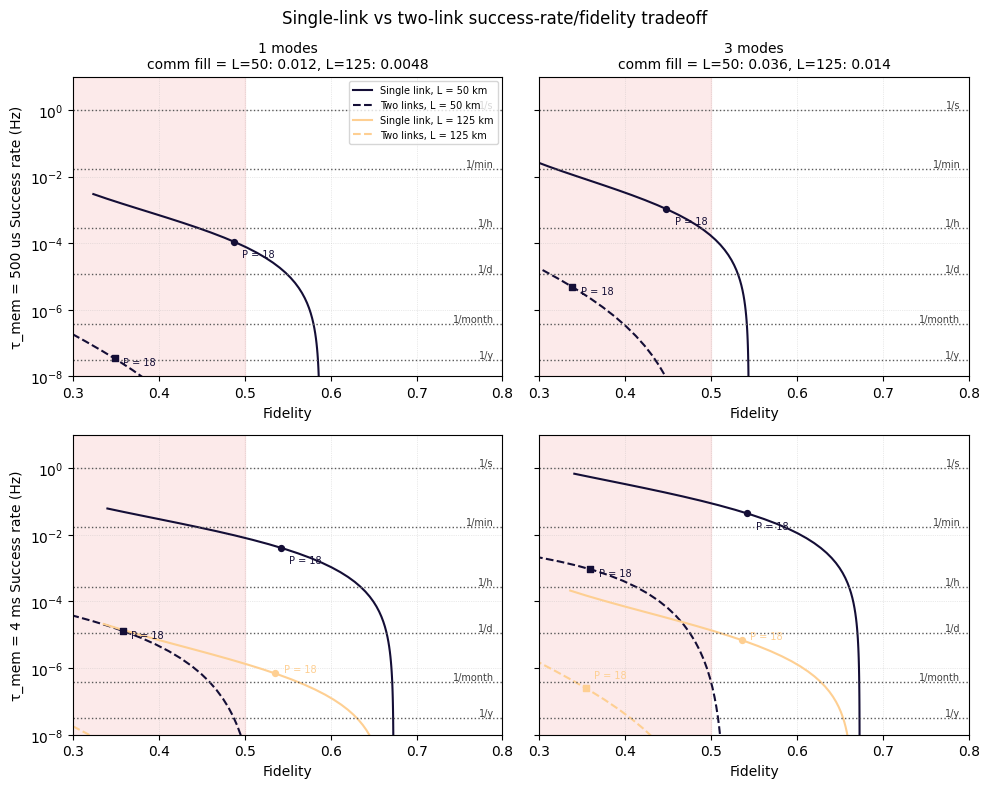

In [20]:
tradeoff_memory_modes = [1, 3]
tradeoff_tau_scans = [500e-6, 4e-3]
tradeoff_tau_labels = ["500 us", "4 ms"]
tradeoff_L_scan = [50, 125]
tradeoff_P_scan = np.logspace(-4, 2, 80)
P_marker = 18
fidelity_warning_threshold = 0.5
L_colors = plt.cm.magma(np.linspace(0.1, 0.9, len(tradeoff_L_scan)))
case_specs = [
    ("Single link", DoubleChainLink, "-", "o"),
    ("Two links", DoubleChainDoubleLink, "--", "s"),
]

fig, axes = plt.subplots(len(tradeoff_tau_scans), len(tradeoff_memory_modes), figsize=(10, 8), sharey=True, squeeze=False)

for row, (tau_now, tau_label) in enumerate(zip(tradeoff_tau_scans, tradeoff_tau_labels)):
    for col, (ax, memory_modes_now) in enumerate(zip(axes[row], tradeoff_memory_modes)):
        fill_fractions = []
        for L_now in tradeoff_L_scan:
            two_way_time = 2 * L_now * params["n"] / params["c"]
            fill_fractions.append(memory_modes_now * params["T_acceptance"] / two_way_time)

        for i, L_now in enumerate(tradeoff_L_scan):
            color = L_colors[i]

            for case_idx, (case_label, link_cls, linestyle, marker) in enumerate(case_specs):
                success_scan = []
                F_scan = []

                for P_now in tradeoff_P_scan:
                    scan_params = params.copy()
                    scan_params["P"] = P_now
                    scan_params["L"] = L_now
                    scan_params["tau_eff"] = tau_now
                    scan_params["T_max"] = tau_now

                    mylink = link_cls(scan_params, memory_modes=memory_modes_now, print_rate=False)
                    mylink.get_rates()
                    mylink.get_fidelity()

                    if link_cls is DoubleChainDoubleLink and memory_modes_now == 1:
                        success_scan.append(mylink.Gamma_2L)
                        F_scan.append(mylink.Fbar_2L_disc)
                    elif link_cls is DoubleChainDoubleLink:
                        success_scan.append(mylink.Gamma_2L_M)
                        F_scan.append(mylink.Fbar_2L_M)
                    else:
                        success_scan.append(mylink.Gamma_succ)
                        F_scan.append(mylink.fidelity)

                success_scan = np.asarray(success_scan)
                F_scan = np.asarray(F_scan)
                valid = np.isfinite(F_scan) & np.isfinite(success_scan) & (success_scan > 0)

                label = f"{case_label}, L = {L_now} km"
                ax.plot(F_scan[valid], success_scan[valid], color=color, linestyle=linestyle, label=label)

                success_at_marker = np.interp(P_marker, tradeoff_P_scan, success_scan)
                fidelity_at_marker = np.interp(P_marker, tradeoff_P_scan, F_scan)
                label_offset = 6 * ((len(case_specs) * i + case_idx) - (len(case_specs) * len(tradeoff_L_scan) - 1) / 2)

                ax.scatter(fidelity_at_marker, success_at_marker, color=color, marker=marker, s=18, zorder=3)
                ax.annotate(
                    f"P = {P_marker:g}",
                    xy=(fidelity_at_marker, success_at_marker),
                    xytext=(6, label_offset),
                    textcoords="offset points",
                    color=color,
                    fontsize=7,
                    va="center",
                )

        ax.set_yscale("log")
        ax.set_ylim(bottom=10e-9)
        ax.set_ylim(top=10)
        ax.set_xlim(0.3, 0.8)
        ax.set_xlabel("Fidelity")
        ax.axvspan(0, fidelity_warning_threshold, color="lightcoral", alpha=0.16, zorder=0)
        ax.grid(True, which="both", linestyle=":", linewidth=0.5, alpha=0.5)
        add_rate_reference_lines(ax)

        if row == 0:
            fill_text = ", ".join(f"L={L_now}: {fill:.2g}" for L_now, fill in zip(tradeoff_L_scan, fill_fractions))
            ax.set_title(f"{memory_modes_now} modes\ncomm fill = {fill_text}", fontsize=10)

    axes[row][0].set_ylabel(f"τ_mem = {tau_label} Success rate (Hz)")

axes[0][0].legend(fontsize=7)
fig.suptitle("Single-link vs two-link success-rate/fidelity tradeoff")
plt.tight_layout()
plt.show()

#### Rate fidelity trade off for different storage times and memory modes, but only good fidelity.

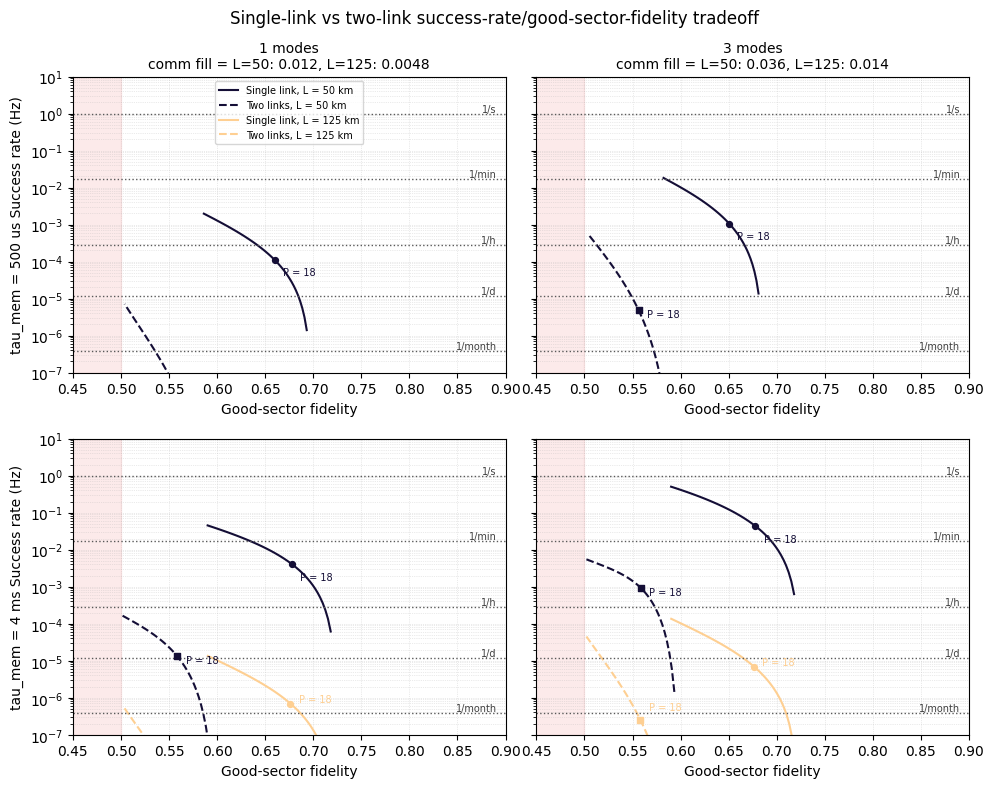

In [21]:
tradeoff_good_memory_modes = [1, 3]
tradeoff_good_tau_scans = [500e-6, 4e-3]
tradeoff_good_tau_labels = ["500 us", "4 ms"]
tradeoff_good_L_scan = [50, 125]
tradeoff_good_P_scan = np.linspace(2, 80, 80)
P_marker = 18
fidelity_warning_threshold = 0.5
L_colors = plt.cm.magma(np.linspace(0.1, 0.9, len(tradeoff_good_L_scan)))
case_specs = [
    ("Single link", DoubleChainLink, "-", "o"),
    ("Two links", DoubleChainDoubleLink, "--", "s"),
]

fig, axes = plt.subplots(len(tradeoff_good_tau_scans), len(tradeoff_good_memory_modes), figsize=(10, 8), sharey=True, squeeze=False)

for row, (tau_now, tau_label) in enumerate(zip(tradeoff_good_tau_scans, tradeoff_good_tau_labels)):
    for col, (ax, memory_modes_now) in enumerate(zip(axes[row], tradeoff_good_memory_modes)):
        fill_fractions = []
        for L_now in tradeoff_good_L_scan:
            two_way_time = 2 * L_now * params["n"] / params["c"]
            fill_fractions.append(memory_modes_now * params["T_acceptance"] / two_way_time)

        for i, L_now in enumerate(tradeoff_good_L_scan):
            color = L_colors[i]

            for case_idx, (case_label, link_cls, linestyle, marker) in enumerate(case_specs):
                success_scan = []
                F_good_scan = []

                for P_now in tradeoff_good_P_scan:
                    scan_params = params.copy()
                    scan_params["P"] = P_now
                    scan_params["L"] = L_now
                    scan_params["tau_eff"] = tau_now
                    scan_params["T_max"] = tau_now

                    mylink = link_cls(scan_params, memory_modes=memory_modes_now, print_rate=False)
                    mylink.get_rates()
                    mylink.get_fidelity_good_sector()

                    if link_cls is DoubleChainDoubleLink and memory_modes_now == 1:
                        success_scan.append(mylink.Gamma_2L)
                    elif link_cls is DoubleChainDoubleLink:
                        success_scan.append(mylink.Gamma_2L_M)
                    else:
                        success_scan.append(mylink.Gamma_succ)
                    F_good_scan.append(mylink.fidelity_good_sector)

                success_scan = np.asarray(success_scan)
                F_good_scan = np.asarray(F_good_scan)
                valid = np.isfinite(F_good_scan) & np.isfinite(success_scan) & (success_scan > 0)

                label = f"{case_label}, L = {L_now} km"
                ax.plot(F_good_scan[valid], success_scan[valid], color=color, linestyle=linestyle, label=label)

                success_at_marker = np.interp(P_marker, tradeoff_good_P_scan, success_scan)
                fidelity_at_marker = np.interp(P_marker, tradeoff_good_P_scan, F_good_scan)
                label_offset = 6 * ((len(case_specs) * i + case_idx) - (len(case_specs) * len(tradeoff_good_L_scan) - 1) / 2)

                ax.scatter(fidelity_at_marker, success_at_marker, color=color, marker=marker, s=18, zorder=3)
                ax.annotate(
                    f"P = {P_marker:g}",
                    xy=(fidelity_at_marker, success_at_marker),
                    xytext=(6, label_offset),
                    textcoords="offset points",
                    color=color,
                    fontsize=7,
                    va="center",
                )

        ax.set_yscale("log")
        ax.set_ylim(bottom=10e-8)
        ax.set_ylim(top=10)
        ax.set_xlim(0.45, 0.9)
        ax.set_xlabel("Good-sector fidelity")
        ax.axvspan(0, fidelity_warning_threshold, color="lightcoral", alpha=0.16, zorder=0)
        ax.grid(True, which="both", linestyle=":", linewidth=0.5, alpha=0.5)
        add_rate_reference_lines(ax)

        if row == 0:
            fill_text = ", ".join(f"L={L_now}: {fill:.2g}" for L_now, fill in zip(tradeoff_good_L_scan, fill_fractions))
            ax.set_title(f"{memory_modes_now} modes\ncomm fill = {fill_text}", fontsize=10)

    axes[row][0].set_ylabel(f"tau_mem = {tau_label} Success rate (Hz)")

axes[0][0].legend(fontsize=7)
fig.suptitle("Single-link vs two-link success-rate/good-sector-fidelity tradeoff")
plt.tight_layout()
plt.show()

# Repeater made of one single chain and on local oscillator 

## LO repeater class

In [22]:
class LOTrickRepeater:
    def __init__(self, params, number_of_links=1, memory_modes=1, n_LO=None, print_rate=False):
        self.params = SimpleNamespace(**params)
        self.number_of_links = number_of_links
        self.memory_modes = int(memory_modes)
        self.n_LO_input = n_LO
        self.print_rate = print_rate
        self.calculate_params()

    def calculate_params(self):
        """Calculate parameters that depend on the selected link geometry."""
        if self.number_of_links not in (1, 2):
            raise ValueError("number_of_links must be 1 or 2")
        if self.memory_modes < 1:
            raise ValueError("memory_modes must be at least 1")

        # For a two-link repeater, params.L is the total distance and each
        # elementary LO link uses half of it, as in DoubleChainDoubleLink.
        if self.number_of_links == 2:
            self.params.L = self.params.L / 2

        self.params.eta_m0 = self.params.eta_AFC0 * self.params.eta_CP**2
        self.params.eta_duty_mem = 1 - self.params.prep_mem / self.params.cycle_mem
        self.params.R0 = self.params.bright / self.params.M
        self.params.g2 = 1 + 1 / (self.params.a * self.params.P)
        self.params.T_max = self.params.tau_eff * 0.5
        self.params.eta_path = self.params.eta_T1 * self.params.eta_T2 * self.params.eta_T3
        self.params.fib = 10 ** (-self.params.alpha * self.params.L / 10)
        self.params.T_L = self.params.L * self.params.n / self.params.c
        self.params.NF = self.params.mu1 * self.params.eta_T2 * self.params.eta_T3 * self.params.eta_d * self.params.eta_m0

        self.params.eta_BSM = 0.5
        self.params.I_HOM = self.params.etaOv

        self.Delta = 2 * self.params.T_L
        self.N = max(0, int(np.floor(self.params.T_max / self.Delta)))
        self.duty = self.params.eta_duty_mem * self.params.eta_duty_chopper * self.params.eta_phase_stab

        self.Gamma_ch = self.params.R0 * self.params.P * self.params.fib * self.params.eta_d * 2
        self.p_h_window = 1 - np.exp(-self.Gamma_ch * self.params.T_acceptance)
        self.p_no_h_window = 1 - self.p_h_window

        # Round-aggregated version of the p -> p_M replacement from the notes.
        self.p_h = 1 - self.p_no_h_window**self.memory_modes
        self.p_no_h = 1 - self.p_h

        self.n_LO = self.n_opt(0) if self.n_LO_input is None else self.n_LO_input

    def _safe_ratio(self, numerator, denominator, default=np.nan):
        if np.isscalar(numerator) and np.isscalar(denominator):
            return default if denominator == 0 else numerator / denominator
        numerator = np.asarray(numerator, dtype=float)
        denominator = np.asarray(denominator, dtype=float)
        shape = np.broadcast_shapes(numerator.shape, denominator.shape)
        out = np.full(shape, default, dtype=float)
        return np.divide(numerator, denominator, out=out, where=denominator != 0)

    # Time-dependent memory and source quantities

    def eta_m(self, t):
        storage_time = 2 * self.params.T_L + t
        return self.params.eta_m0 * np.exp(-storage_time**2 / self.params.tau_eff**2)

    def g2_sw(self,t):
        # from swappinger PRX
        return self.params.g2 * (self.params.eta_h * self.eta_m(t) * self.params.eta_T2 * self.params.eta_T3 * self.params.eta_d / self.params.NF + 1) / (self.params.g2 + self.params.eta_h * self.eta_m(t) * self.params.eta_T2 * self.params.eta_T3 * self.params.eta_d / self.params.NF)

    def Vcal(self, t):
        phase_factor = np.exp(-(self.params.sigma_phase**2) / 2)
        return (self.g2_sw(t) - 1) / (self.g2_sw(t) + 1) * phase_factor * self.params.etaOv **2 * self.params.etaclass

    # Probabilities conditioned on an idler herald

    def p10(self, t):
        return self.eta_m(t) * self.params.eta_path * self.params.eta_d * self.params.eta_h / 2

    def p01(self, t):
        return self.p10(t)

    def p11(self, t):
        return 4 * self.p10(t) * self.p10(t) * (self.g2_sw(t) - 1) / (self.g2_sw(t) * self.g2_sw(t))

    def p00(self, t):
        return np.maximum(1 - self.p01(t) - self.p10(t) - self.p11(t), 0)

    # LO postselection quantities

    def ell(self, n):
        return 1 - np.exp(-n)

    def n_opt(self, t=0):
        return np.sqrt(self._safe_ratio(self.p11(t), self.p00(t), default=0))

    def G(self, t, n=None):
        n = self.n_LO if n is None else n
        return (self.p01(t) + self.p10(t)) * self.ell(n) * np.exp(-n)

    def B(self, t, n=None):
        n = self.n_LO if n is None else n
        return self.p00(t) * self.ell(n)**2 + self.p11(t) * np.exp(-2 * n)

    def Z(self, t, n=None):
        return self.G(t, n) + self.B(t, n)

    def beta(self, t, n=None):
        return self._safe_ratio(self.B(t, n), self.G(t, n), default=np.inf)

    def useful_fraction(self, t, n=None):
        return self._safe_ratio(self.G(t, n), self.Z(t, n), default=0)

    # calculation methods

    def get_rates(self):
        if self.number_of_links == 1:
            self._get_single_link_rates()
        else:
            self._get_double_link_rates()

        if self.print_rate:
            print(f"LO photon number n: {self.n_LO:.4g}")
            print(f"Ready rate: {self.Gamma_ready:.4g} Hz")
            print(f"Success rate: {self.Gamma_succ:.4e} Hz")
            print(f"Number of rounds before giving up: {int(self.N)}")

    def _get_single_link_rates(self):
        self.Gamma_ready = self.p_h / (self.Delta + self.p_h * self.params.lat) * self.duty
        self.P_LO_given_h = self.Z(0)
        self.Gamma_succ = self.Gamma_ready * self.P_LO_given_h

    def _get_double_link_rates(self):
        p = self.p_h
        q = self.p_no_h

        self.W_ready = p**2 + 2 * p * q * (1 - q**self.N)
        non_empty = 1 - q**2
        cycle_rounds = 1 + 2 * q * (1 - q**self.N)

        if non_empty == 0:
            self.P_ready_conditioned_non_empty = 0
            self.T_cycle = np.inf
            self.Gamma_ready = 0
        else:
            self.P_ready_conditioned_non_empty = self.W_ready / non_empty
            self.T_cycle = cycle_rounds / non_empty * self.Delta + self.P_ready_conditioned_non_empty * self.params.lat
            self.Gamma_ready = self.P_ready_conditioned_non_empty / self.T_cycle * self.duty

        Z0 = self.Z(0)
        postselection_weight = p**2 * Z0**2
        postselection_weight += 2 * p**2 * sum(q**j * self.Z(j * self.Delta) * Z0 for j in range(1, self.N + 1))

        self.P_LO_given_ready = self._safe_ratio(postselection_weight, self.W_ready, default=0)
        self.P_succ_given_ready = self.params.eta_BSM * self.P_LO_given_ready
        self.Gamma_succ = self.Gamma_ready * self.P_succ_given_ready

    def get_fidelity(self):
        if not hasattr(self, "Gamma_succ"):
            self.get_rates()

        if self.number_of_links == 1:
            self._get_single_link_fidelity()
        else:
            self._get_double_link_fidelity()

        if self.print_rate:
            print(f"Fidelity: {self.fidelity:.4f}")

    def _get_single_link_fidelity(self):
        self.fidelity = self.useful_fraction(0) * (1 + self.Vcal(0)) / 2
        self.F_LO_1L = self.fidelity

    def _get_double_link_fidelity(self):
        q = self.p_no_h
        Z0 = self.Z(0)
        s0 = self.useful_fraction(0)
        V0 = self.Vcal(0)

        den = Z0**2 + 2 * sum(q**j * self.Z(j * self.Delta) * Z0 for j in range(1, self.N + 1))

        num = Z0**2 * s0**2 * (1 + self.params.I_HOM * V0**2)
        num += 2 * sum(
            q**j
            * self.Z(j * self.Delta)
            * Z0
            * self.useful_fraction(j * self.Delta)
            * s0
            * (1 + self.params.I_HOM * self.Vcal(j * self.Delta) * V0)
            for j in range(1, self.N + 1)
        )

        self.fidelity = np.nan if den == 0 else 0.5 * num / den
        self.F_LO_2L = self.fidelity


## LO single link

#### Single-link calculation

In [23]:
lo_single_params = params.copy()
lo_single_params["P"] = 18
lo_single_params["L"] = 50

lo_single = LOTrickRepeater(lo_single_params, number_of_links=1, print_rate=True)
lo_single.get_rates()
lo_single.get_fidelity()
print(f"Pump power P: {lo_single.params.P} mW")
print(f"Link length L: {lo_single.params.L} km")
print(f"LO photon number n: {lo_single.n_LO:.4g}")
print(f"Tau_eff: {lo_single.params.tau_eff*1e3:.3g} ms")

LO photon number n: 0.01439
Ready rate: 18.47 Hz
Success rate: 2.1134e-02 Hz
Number of rounds before giving up: 3
Fidelity: 0.5338
Pump power P: 18 mW
Link length L: 50 km
LO photon number n: 0.01439
Tau_eff: 4 ms


#### Rates and fidelities for optimized LO photon number

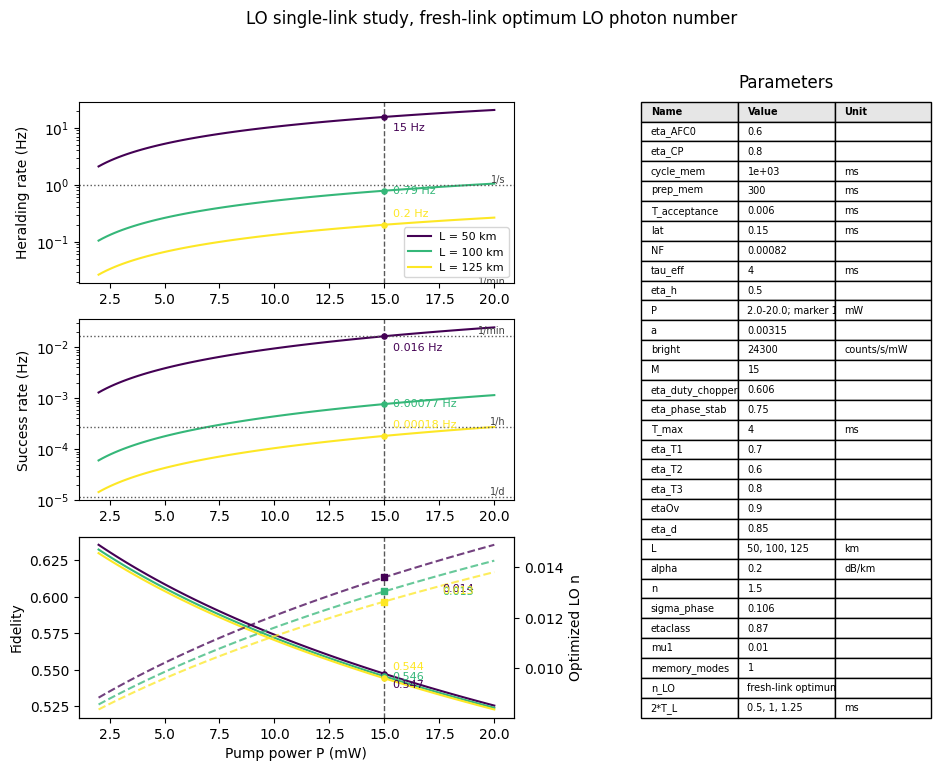

In [24]:
lo_single_L_scan = [50, 100, 125]
lo_single_P_scan = np.linspace(2, 20, 100)
lo_single_P_marker = 15

cmap = plt.cm.viridis
norm = plt.Normalize(min(lo_single_L_scan), max(lo_single_L_scan))

table_params = params.copy()
table_params["P"] = f"{lo_single_P_scan[0]:.1f}-{lo_single_P_scan[-1]:.1f}; marker {lo_single_P_marker:g}"
table_params["L"] = ", ".join(str(L) for L in lo_single_L_scan)
table_params["memory_modes"] = 1
table_params["n_LO"] = "fresh-link optimum at each point"
table_params["2*T_L"] = ", ".join(f"{2 * L * params['n'] / params['c'] * 1e3:.3g}" for L in lo_single_L_scan)
table_params.pop("c", None)

time_params = {"cycle_mem", "prep_mem", "T_acceptance", "lat", "tau_eff", "T_max", "T_L"}
param_units = {
    "cycle_mem": "ms",
    "prep_mem": "ms",
    "T_acceptance": "ms",
    "lat": "ms",
    "tau_eff": "ms",
    "P": "mW",
    "bright": "counts/s/mW",
    "T_max": "ms",
    "L": "km",
    "alpha": "dB/km",
    "2*T_L": "ms",
}

table_rows = []
for name, value in table_params.items():
    if name in time_params and isinstance(value, (int, float)):
        value = f"{value * 1e3:.3g}"
    elif isinstance(value, float):
        value = f"{value:.3g}"
    table_rows.append([name, value, param_units.get(name, "")])

fig = plt.figure(figsize=(11, 8))
gs = fig.add_gridspec(3, 2, width_ratios=[3, 2], wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
ax3 = fig.add_subplot(gs[2, 0], sharex=ax1)
ax3_n = ax3.twinx()
ax_table = fig.add_subplot(gs[:, 1])
ax_table.axis("off")

for i, L_now in enumerate(lo_single_L_scan):
    color = cmap(norm(L_now))
    ready_scan = []
    success_scan = []
    F_scan = []
    n_scan = []

    for P_now in lo_single_P_scan:
        scan_params = params.copy()
        scan_params["P"] = P_now
        scan_params["L"] = L_now
        mylink = LOTrickRepeater(scan_params, number_of_links=1, print_rate=False)
        mylink.get_rates()
        mylink.get_fidelity()
        ready_scan.append(mylink.Gamma_ready)
        success_scan.append(mylink.Gamma_succ)
        F_scan.append(mylink.fidelity)
        n_scan.append(mylink.n_LO)

    ready_at_marker = np.interp(lo_single_P_marker, lo_single_P_scan, ready_scan)
    succ_at_marker = np.interp(lo_single_P_marker, lo_single_P_scan, success_scan)
    fidelity_at_marker = np.interp(lo_single_P_marker, lo_single_P_scan, F_scan)
    n_at_marker = np.interp(lo_single_P_marker, lo_single_P_scan, n_scan)
    label_offset = 8 * (i - (len(lo_single_L_scan) - 1) / 2)

    ax1.plot(lo_single_P_scan, ready_scan, color=color, label=f"L = {L_now} km")
    ax1.scatter(lo_single_P_marker, ready_at_marker, color=color, s=14, zorder=3)
    ax1.annotate(f"{ready_at_marker:.2g} Hz", xy=(lo_single_P_marker, ready_at_marker), xytext=(6, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")

    ax2.plot(lo_single_P_scan, success_scan, color=color)
    ax2.scatter(lo_single_P_marker, succ_at_marker, color=color, s=14, zorder=3)
    ax2.annotate(f"{succ_at_marker:.2g} Hz", xy=(lo_single_P_marker, succ_at_marker), xytext=(6, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")

    ax3.plot(lo_single_P_scan, F_scan, color=color)
    ax3_n.plot(lo_single_P_scan, n_scan, color=color, linestyle="--", alpha=0.75)
    ax3.scatter(lo_single_P_marker, fidelity_at_marker, color=color, s=14, zorder=3)
    ax3_n.scatter(lo_single_P_marker, n_at_marker, color=color, marker="s", s=14, zorder=3)
    ax3.annotate(f"{fidelity_at_marker:.3f}", xy=(lo_single_P_marker, fidelity_at_marker), xytext=(6, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")
    ax3_n.annotate(f"{n_at_marker:.2g}", xy=(lo_single_P_marker, n_at_marker), xytext=(42, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")

ax1.set_ylabel("Heralding rate (Hz)")
ax2.set_ylabel("Success rate (Hz)")
ax3.set_xlabel("Pump power P (mW)")
ax3.set_ylabel("Fidelity")
ax3_n.set_ylabel("Optimized LO n")
ax1.set_yscale("log")
ax2.set_yscale("log")
add_rate_reference_lines(ax1)
add_rate_reference_lines(ax2)
for ax in (ax1, ax2, ax3):
    ax.axvline(lo_single_P_marker, color="0.35", linestyle="--", linewidth=1)
ax1.legend(fontsize=8)

param_table = ax_table.table(
    cellText=table_rows,
    colLabels=["Name", "Value", "Unit"],
    cellLoc="left",
    colLoc="left",
    loc="center",
    bbox=[0, 0, 1, 1],
)
param_table.auto_set_font_size(False)
param_table.set_fontsize(7)
param_table.scale(1, 1.15)
for (row, col), cell in param_table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("0.9")
ax_table.set_title("Parameters", pad=10)
fig.suptitle("LO single-link study, fresh-link optimum LO photon number", y=0.995)
plt.show()


#### Rate-fidelity tradeoff versus LO photon number

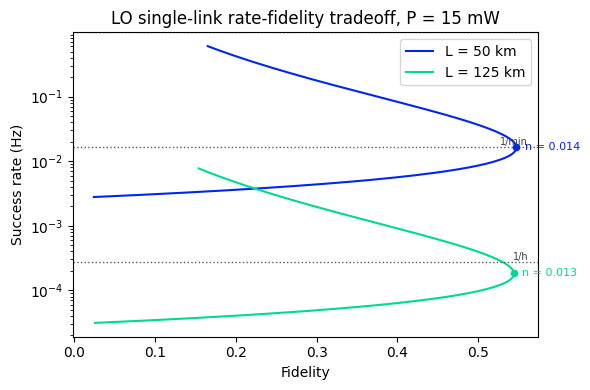

In [25]:
lo_single_n_scan = np.geomspace(1e-4, 0.2, 160)
lo_single_tradeoff_L_scan = [50, 125]
lo_single_tradeoff_P = 15

colors = plt.cm.winter(np.linspace(0.15, 0.85, len(lo_single_tradeoff_L_scan)))
fig, ax = plt.subplots(figsize=(6, 4))

for color, L_now in zip(colors, lo_single_tradeoff_L_scan):
    success_scan = []
    F_scan = []

    for n_now in lo_single_n_scan:
        scan_params = params.copy()
        scan_params["P"] = lo_single_tradeoff_P
        scan_params["L"] = L_now
        mylink = LOTrickRepeater(scan_params, number_of_links=1, n_LO=n_now, print_rate=False)
        mylink.get_rates()
        mylink.get_fidelity()
        success_scan.append(mylink.Gamma_succ)
        F_scan.append(mylink.fidelity)

    opt_link = LOTrickRepeater({**params, "P": lo_single_tradeoff_P, "L": L_now}, number_of_links=1, print_rate=False)
    opt_link.get_rates()
    opt_link.get_fidelity()

    ax.plot(F_scan, success_scan, color=color, label=f"L = {L_now} km")
    ax.scatter(opt_link.fidelity, opt_link.Gamma_succ, color=color, s=20, zorder=3)
    ax.annotate(
        f"n = {opt_link.n_LO:.2g}",
        xy=(opt_link.fidelity, opt_link.Gamma_succ),
        xytext=(6, 0),
        textcoords="offset points",
        color=color,
        fontsize=8,
        va="center",
    )

ax.set_xlabel("Fidelity")
ax.set_ylabel("Success rate (Hz)")
ax.set_yscale("log")
add_rate_reference_lines(ax)
ax.legend()
ax.set_title(f"LO single-link rate-fidelity tradeoff, P = {lo_single_tradeoff_P:g} mW")
plt.tight_layout()
plt.show()


#### Fidelity and succes vs LO photon number and pump power P in other axis.

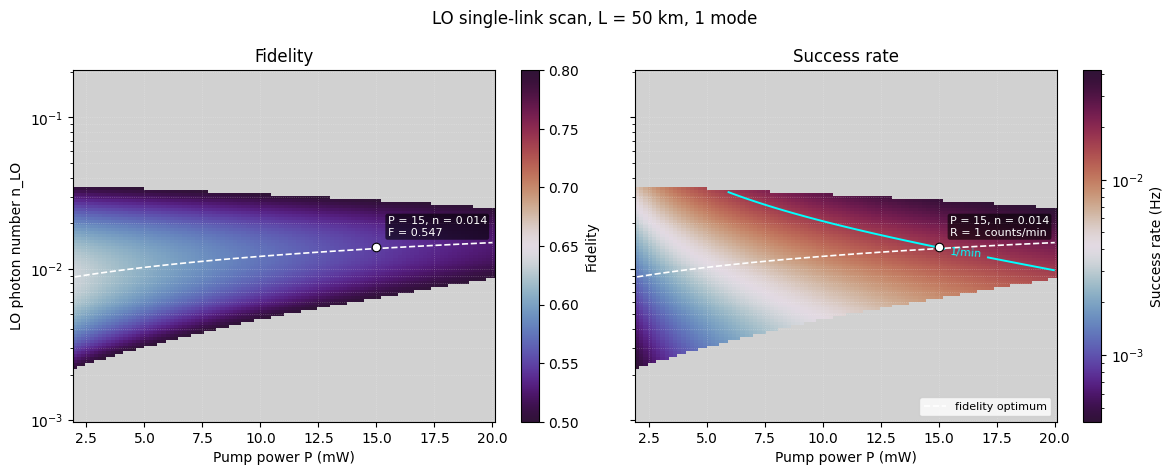

In [26]:
from matplotlib.colors import LogNorm

lo_colormap_L = 50
lo_colormap_memory_modes = 1
lo_colormap_P_scan = np.linspace(2, 20, 100)
lo_colormap_n_scan = np.geomspace(1e-3, 0.2, 120)
lo_colormap_marker_P = 15
lo_colormap_marker_n = 0.014

fidelity_grid = np.full((len(lo_colormap_n_scan), len(lo_colormap_P_scan)), np.nan)
success_grid = np.full_like(fidelity_grid, np.nan)
optimal_n_scan = []

for col, P_now in enumerate(lo_colormap_P_scan):
    opt_link = LOTrickRepeater(
        {**params, "P": P_now, "L": lo_colormap_L},
        number_of_links=1,
        memory_modes=lo_colormap_memory_modes,
        print_rate=False,
    )
    optimal_n_scan.append(opt_link.n_LO)

    for row, n_now in enumerate(lo_colormap_n_scan):
        scan_params = params.copy()
        scan_params["P"] = P_now
        scan_params["L"] = lo_colormap_L

        mylink = LOTrickRepeater(
            scan_params,
            number_of_links=1,
            memory_modes=lo_colormap_memory_modes,
            n_LO=n_now,
            print_rate=False,
        )
        mylink.get_rates()
        mylink.get_fidelity()

        fidelity_grid[row, col] = mylink.fidelity
        success_grid[row, col] = mylink.Gamma_succ

optimal_n_scan = np.asarray(optimal_n_scan)
marker_params = params.copy()
marker_params["P"] = lo_colormap_marker_P
marker_params["L"] = lo_colormap_L
marker_link = LOTrickRepeater(
    marker_params,
    number_of_links=1,
    memory_modes=lo_colormap_memory_modes,
    n_LO=lo_colormap_marker_n,
    print_rate=False,
)
marker_link.get_rates()
marker_link.get_fidelity()
marker_fidelity = marker_link.fidelity
marker_rate_per_minute = 60 * marker_link.Gamma_succ

fidelity_threshold = 0.5
low_fidelity_mask = fidelity_grid < fidelity_threshold

fidelity_grid_masked = np.ma.masked_where(low_fidelity_mask, fidelity_grid)
success_grid_masked = np.ma.masked_where(
    low_fidelity_mask,
    np.ma.masked_invalid(np.where(success_grid > 0, success_grid, np.nan)),
)

fidelity_cmap = plt.cm.twilight_shifted.copy()
fidelity_cmap.set_bad("0.82")
success_cmap = plt.cm.twilight_shifted.copy()
success_cmap.set_bad("0.82")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True, sharey=True)

fid_mesh = axes[0].pcolormesh(
    lo_colormap_P_scan,
    lo_colormap_n_scan,
    fidelity_grid_masked,
    shading="auto",
    cmap=fidelity_cmap,
    vmin=fidelity_threshold,
    vmax=0.8,
)
rate_mesh = axes[1].pcolormesh(
    lo_colormap_P_scan,
    lo_colormap_n_scan,
    success_grid_masked,
    shading="auto",
    cmap=success_cmap,
    norm=LogNorm(vmin=success_grid_masked.min(), vmax=success_grid_masked.max()),
)
add_rate_reference_contours(
    axes[1],
    lo_colormap_P_scan,
    lo_colormap_n_scan,
    success_grid_masked,
)

for ax in axes:
    ax.scatter(
        lo_colormap_marker_P,
        lo_colormap_marker_n,
        color="white",
        edgecolor="black",
        linewidth=0.8,
        s=38,
        zorder=5,
    )

axes[0].annotate(
    f"P = {lo_colormap_marker_P:g}, n = {lo_colormap_marker_n:g}\nF = {marker_fidelity:.3f}",
    xy=(lo_colormap_marker_P, lo_colormap_marker_n),
    xytext=(8, 8),
    textcoords="offset points",
    color="white",
    fontsize=8,
    bbox={"boxstyle": "round,pad=0.2", "facecolor": "black", "edgecolor": "none", "alpha": 0.6},
    zorder=6,
)
axes[1].annotate(
    f"P = {lo_colormap_marker_P:g}, n = {lo_colormap_marker_n:g}\nR = {marker_rate_per_minute:.2g} counts/min",
    xy=(lo_colormap_marker_P, lo_colormap_marker_n),
    xytext=(8, 8),
    textcoords="offset points",
    color="white",
    fontsize=8,
    bbox={"boxstyle": "round,pad=0.2", "facecolor": "black", "edgecolor": "none", "alpha": 0.6},
    zorder=6,
)

for ax in axes:
    ax.plot(lo_colormap_P_scan, optimal_n_scan, color="white", linestyle="--", linewidth=1.2, label="fidelity optimum")
    ax.set_yscale("log")
    ax.set_xlabel("Pump power P (mW)")
    ax.grid(True, which="both", linestyle=":", linewidth=0.5, color="white", alpha=0.35)

axes[0].set_ylabel("LO photon number n_LO")
axes[0].set_title("Fidelity")
axes[1].set_title("Success rate")
axes[1].legend(loc="lower right", fontsize=8)

fig.colorbar(fid_mesh, ax=axes[0], label="Fidelity")
fig.colorbar(rate_mesh, ax=axes[1], label="Success rate (Hz)")
fig.suptitle(f"LO single-link scan, L = {lo_colormap_L:g} km, {lo_colormap_memory_modes} mode")
plt.tight_layout()
plt.show()

## LO two links

#### Two-link calculation

In [27]:
lo_double_params = params.copy()
lo_double_params["P"] = 18
lo_double_params["L"] = 50

lo_double = LOTrickRepeater(lo_double_params, number_of_links=2, print_rate=True)
lo_double.get_rates()
lo_double.get_fidelity()


LO photon number n: 0.01455
Ready rate: 57.25 Hz
Success rate: 3.6207e-05 Hz
Number of rounds before giving up: 7
Fidelity: 0.2924


#### Rates and fidelities for optimized LO photon number

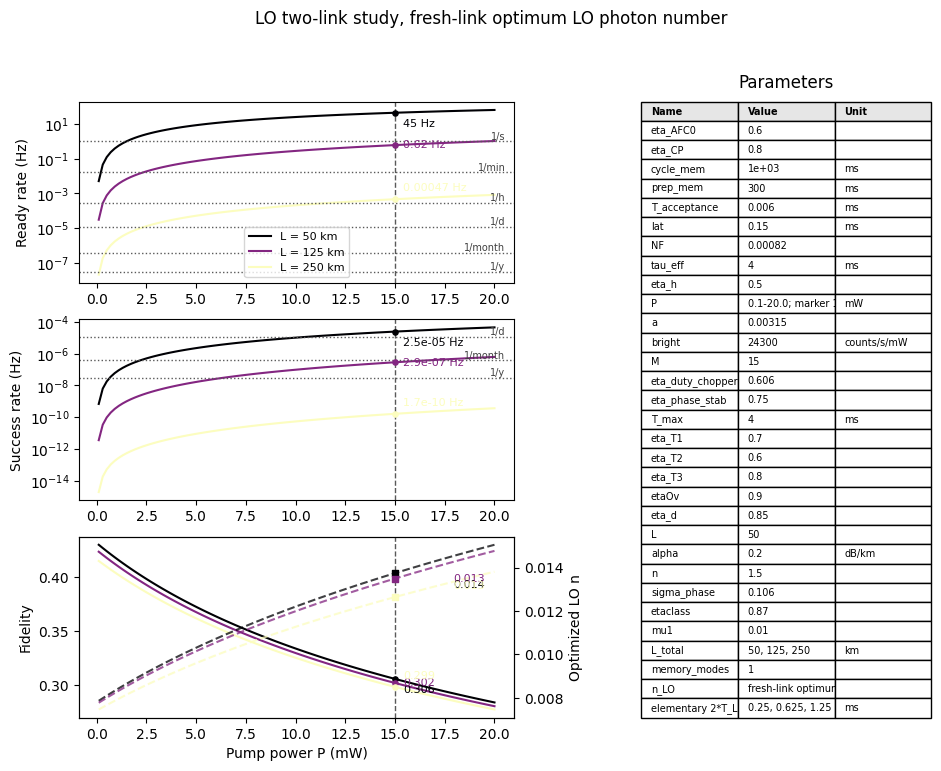

In [28]:
lo_double_L_scan = [50, 125, 250]
lo_double_P_scan = np.linspace(0.1, 20, 100)
lo_double_P_marker = 15

cmap = plt.cm.magma
norm = plt.Normalize(min(lo_double_L_scan), max(lo_double_L_scan))

table_params = params.copy()
table_params["P"] = f"{lo_double_P_scan[0]:.1f}-{lo_double_P_scan[-1]:.1f}; marker {lo_double_P_marker:g}"
table_params["L_total"] = ", ".join(str(L) for L in lo_double_L_scan)
table_params["memory_modes"] = 1
table_params["n_LO"] = "fresh-link optimum at each point"
table_params["elementary 2*T_L"] = ", ".join(f"{L * params['n'] / params['c'] * 1e3:.3g}" for L in lo_double_L_scan)
table_params.pop("c", None)

time_params = {"cycle_mem", "prep_mem", "T_acceptance", "lat", "tau_eff", "T_max", "T_L"}
param_units = {
    "cycle_mem": "ms",
    "prep_mem": "ms",
    "T_acceptance": "ms",
    "lat": "ms",
    "tau_eff": "ms",
    "P": "mW",
    "bright": "counts/s/mW",
    "T_max": "ms",
    "L_total": "km",
    "alpha": "dB/km",
    "elementary 2*T_L": "ms",
}

table_rows = []
for name, value in table_params.items():
    if name in time_params and isinstance(value, (int, float)):
        value = f"{value * 1e3:.3g}"
    elif isinstance(value, float):
        value = f"{value:.3g}"
    table_rows.append([name, value, param_units.get(name, "")])

fig = plt.figure(figsize=(11, 8))
gs = fig.add_gridspec(3, 2, width_ratios=[3, 2], wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
ax3 = fig.add_subplot(gs[2, 0], sharex=ax1)
ax3_n = ax3.twinx()
ax_table = fig.add_subplot(gs[:, 1])
ax_table.axis("off")

for i, L_now in enumerate(lo_double_L_scan):
    color = cmap(norm(L_now))
    ready_scan = []
    success_scan = []
    F_scan = []
    n_scan = []

    for P_now in lo_double_P_scan:
        scan_params = params.copy()
        scan_params["P"] = P_now
        scan_params["L"] = L_now
        mylink = LOTrickRepeater(scan_params, number_of_links=2, print_rate=False)
        mylink.get_rates()
        mylink.get_fidelity()
        ready_scan.append(mylink.Gamma_ready)
        success_scan.append(mylink.Gamma_succ)
        F_scan.append(mylink.fidelity)
        n_scan.append(mylink.n_LO)

    ready_at_marker = np.interp(lo_double_P_marker, lo_double_P_scan, ready_scan)
    succ_at_marker = np.interp(lo_double_P_marker, lo_double_P_scan, success_scan)
    fidelity_at_marker = np.interp(lo_double_P_marker, lo_double_P_scan, F_scan)
    n_at_marker = np.interp(lo_double_P_marker, lo_double_P_scan, n_scan)
    label_offset = 8 * (i - (len(lo_double_L_scan) - 1) / 2)

    ax1.plot(lo_double_P_scan, ready_scan, color=color, label=f"L = {L_now} km")
    ax1.scatter(lo_double_P_marker, ready_at_marker, color=color, s=14, zorder=3)
    ax1.annotate(f"{ready_at_marker:.2g} Hz", xy=(lo_double_P_marker, ready_at_marker), xytext=(6, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")

    ax2.plot(lo_double_P_scan, success_scan, color=color)
    ax2.scatter(lo_double_P_marker, succ_at_marker, color=color, s=14, zorder=3)
    ax2.annotate(f"{succ_at_marker:.2g} Hz", xy=(lo_double_P_marker, succ_at_marker), xytext=(6, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")

    ax3.plot(lo_double_P_scan, F_scan, color=color)
    ax3_n.plot(lo_double_P_scan, n_scan, color=color, linestyle="--", alpha=0.75)
    ax3.scatter(lo_double_P_marker, fidelity_at_marker, color=color, s=14, zorder=3)
    ax3_n.scatter(lo_double_P_marker, n_at_marker, color=color, marker="s", s=14, zorder=3)
    ax3.annotate(f"{fidelity_at_marker:.3f}", xy=(lo_double_P_marker, fidelity_at_marker), xytext=(6, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")
    ax3_n.annotate(f"{n_at_marker:.2g}", xy=(lo_double_P_marker, n_at_marker), xytext=(42, label_offset), textcoords="offset points", color=color, fontsize=8, va="center")

ax1.set_ylabel("Ready rate (Hz)")
ax2.set_ylabel("Success rate (Hz)")
ax3.set_xlabel("Pump power P (mW)")
ax3.set_ylabel("Fidelity")
ax3_n.set_ylabel("Optimized LO n")
ax1.set_yscale("log")
ax2.set_yscale("log")
add_rate_reference_lines(ax1)
add_rate_reference_lines(ax2)
for ax in (ax1, ax2, ax3):
    ax.axvline(lo_double_P_marker, color="0.35", linestyle="--", linewidth=1)
ax1.legend(fontsize=8)

param_table = ax_table.table(
    cellText=table_rows,
    colLabels=["Name", "Value", "Unit"],
    cellLoc="left",
    colLoc="left",
    loc="center",
    bbox=[0, 0, 1, 1],
)
param_table.auto_set_font_size(False)
param_table.set_fontsize(7)
param_table.scale(1, 1.15)
for (row, col), cell in param_table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("0.9")
ax_table.set_title("Parameters", pad=10)
fig.suptitle("LO two-link study, fresh-link optimum LO photon number", y=0.995)
plt.show()


#### Rate-fidelity tradeoff versus LO photon number

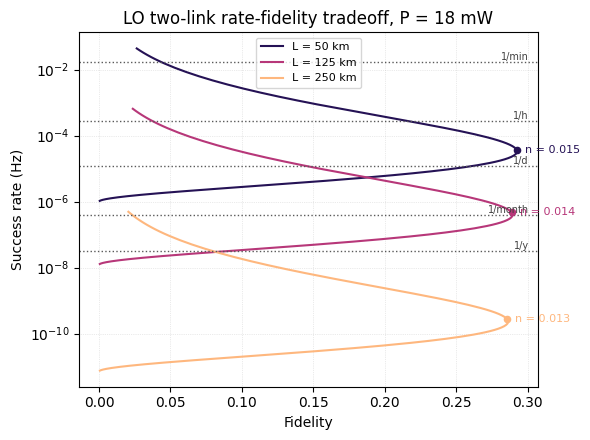

In [29]:
lo_double_n_scan = np.geomspace(1e-4, 0.2, 160)
lo_double_tradeoff_L_scan = [50, 125, 250]
lo_double_tradeoff_P = 18
colors = plt.cm.magma(np.linspace(0.15, 0.85, len(lo_double_tradeoff_L_scan)))
fig, ax = plt.subplots(figsize=(6, 4.5))

for color, L_now in zip(colors, lo_double_tradeoff_L_scan):
    success_scan = []
    F_scan = []

    for n_now in lo_double_n_scan:
        scan_params = params.copy()
        scan_params["P"] = lo_double_tradeoff_P
        scan_params["L"] = L_now
        mylink = LOTrickRepeater(scan_params, number_of_links=2, n_LO=n_now, print_rate=False)
        mylink.get_rates()
        mylink.get_fidelity()
        success_scan.append(mylink.Gamma_succ)
        F_scan.append(mylink.fidelity)

    opt_link = LOTrickRepeater({**params, "P": lo_double_tradeoff_P, "L": L_now}, number_of_links=2, print_rate=False)
    opt_link.get_rates()
    opt_link.get_fidelity()

    success_scan = np.asarray(success_scan)
    F_scan = np.asarray(F_scan)
    valid = np.isfinite(F_scan) & np.isfinite(success_scan) & (success_scan > 0)

    ax.plot(F_scan[valid], success_scan[valid], color=color, label=f"L = {L_now} km")
    ax.scatter(opt_link.fidelity, opt_link.Gamma_succ, color=color, s=20, zorder=3)
    ax.annotate(
        f"n = {opt_link.n_LO:.2g}",
        xy=(opt_link.fidelity, opt_link.Gamma_succ),
        xytext=(6, 0),
        textcoords="offset points",
        color=color,
        fontsize=8,
        va="center",
    )

ax.set_xlabel("Fidelity")
ax.set_ylabel("Success rate (Hz)")
ax.set_yscale("log")
add_rate_reference_lines(ax)
ax.grid(True, which="both", linestyle=":", linewidth=0.5, alpha=0.5)
ax.legend(fontsize=8)
ax.set_title(f"LO two-link rate-fidelity tradeoff, P = {lo_double_tradeoff_P:g} mW")
plt.tight_layout()
plt.show()


#### LO single-link vs two-link rate-fidelity tradeoff for different storage times and memory modes

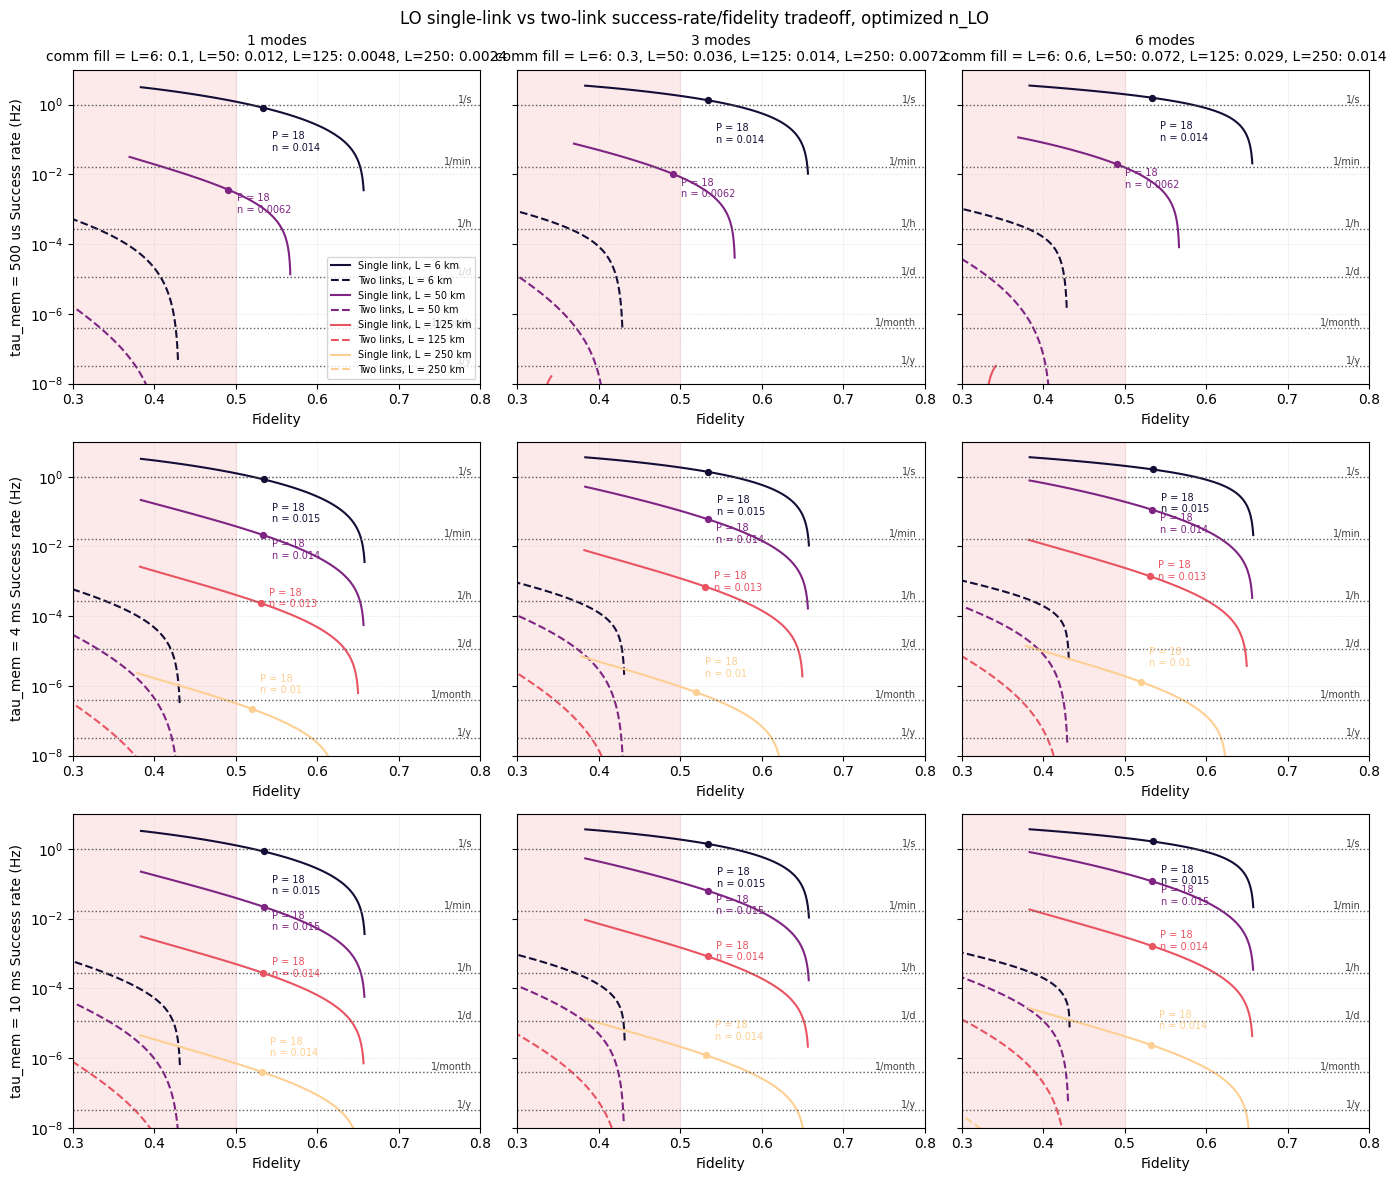

In [30]:
lo_compare_memory_modes = [1, 3, 6]
lo_compare_tau_scans = [500e-6, 4e-3, 10e-3]
lo_compare_tau_labels = ["500 us", "4 ms", "10 ms"]
lo_compare_L_scan = [6, 50, 125, 250]
lo_compare_P_scan = np.logspace(-1, 2, 80)
P_marker = 18
fidelity_warning_threshold = 0.5
L_colors = plt.cm.magma(np.linspace(0.1, 0.9, len(lo_compare_L_scan)))
case_specs = [
    ("Single link", 1, "-", "o"),
    ("Two links", 2, "--", "s"),
]

fig, axes = plt.subplots(len(lo_compare_tau_scans), len(lo_compare_memory_modes), figsize=(14, 12), sharey=True, squeeze=False)

for row, (tau_now, tau_label) in enumerate(zip(lo_compare_tau_scans, lo_compare_tau_labels)):
    for col, (ax, memory_modes_now) in enumerate(zip(axes[row], lo_compare_memory_modes)):
        fill_fractions = []
        for L_now in lo_compare_L_scan:
            two_way_time = 2 * L_now * params["n"] / params["c"]
            fill_fractions.append(memory_modes_now * params["T_acceptance"] / two_way_time)

        for i, L_now in enumerate(lo_compare_L_scan):
            color = L_colors[i]

            for case_idx, (case_label, number_of_links, linestyle, marker) in enumerate(case_specs):
                success_scan = []
                F_scan = []
                n_scan = []

                for P_now in lo_compare_P_scan:
                    scan_params = params.copy()
                    scan_params["P"] = P_now
                    scan_params["L"] = L_now
                    scan_params["tau_eff"] = tau_now
                    scan_params["T_max"] = tau_now

                    mylink = LOTrickRepeater(
                        scan_params,
                        number_of_links=number_of_links,
                        memory_modes=memory_modes_now,
                        print_rate=False,
                    )
                    mylink.get_rates()
                    mylink.get_fidelity()

                    success_scan.append(mylink.Gamma_succ)
                    F_scan.append(mylink.fidelity)
                    n_scan.append(mylink.n_LO)

                success_scan = np.asarray(success_scan)
                F_scan = np.asarray(F_scan)
                n_scan = np.asarray(n_scan)
                valid = np.isfinite(F_scan) & np.isfinite(success_scan) & (success_scan > 0)

                label = f"{case_label}, L = {L_now} km"
                ax.plot(F_scan[valid], success_scan[valid], color=color, linestyle=linestyle, label=label)

                success_at_marker = np.interp(P_marker, lo_compare_P_scan, success_scan)
                fidelity_at_marker = np.interp(P_marker, lo_compare_P_scan, F_scan)
                n_at_marker = np.interp(P_marker, lo_compare_P_scan, n_scan)
                label_offset = 7 * ((len(case_specs) * i + case_idx) - (len(case_specs) * len(lo_compare_L_scan) - 1) / 2)

                ax.scatter(fidelity_at_marker, success_at_marker, color=color, marker=marker, s=18, zorder=3)
                ax.annotate(
                    f"P = {P_marker:g}\nn = {n_at_marker:.2g}",
                    xy=(fidelity_at_marker, success_at_marker),
                    xytext=(6, label_offset),
                    textcoords="offset points",
                    color=color,
                    fontsize=7,
                    va="center",
                )

        ax.set_yscale("log")
        ax.set_ylim(bottom=10e-9, top=10)
        ax.set_xlim(0.3, 0.8)
        ax.set_xlabel("Fidelity")
        ax.axvspan(0, fidelity_warning_threshold, color="lightcoral", alpha=0.16, zorder=0)
        ax.grid(True, which="both", linestyle=":", linewidth=0.5, alpha=0.5)
        add_rate_reference_lines(ax)

        if row == 0:
            fill_text = ", ".join(f"L={L_now}: {fill:.2g}" for L_now, fill in zip(lo_compare_L_scan, fill_fractions))
            ax.set_title(f"{memory_modes_now} modes\ncomm fill = {fill_text}", fontsize=10)

    axes[row][0].set_ylabel(f"tau_mem = {tau_label} Success rate (Hz)")

axes[0][0].legend(fontsize=7)
fig.suptitle("LO single-link vs two-link success-rate/fidelity tradeoff, optimized n_LO")
plt.tight_layout()
plt.show()


# Comparison LO and double chain

#### Single-link comparison setup

LO curves use the fresh-link optimum LO photon number at each scan point. Double-chain curves use the single-link model above, so both plotted fidelities include the accepted bad sectors.

In [31]:
def lo_dc_single_link_metrics(scheme, scan_params, memory_modes=1):
    if scheme == 'LO':
        link = LOTrickRepeater(scan_params, number_of_links=1, memory_modes=memory_modes, print_rate=False)
        link.get_rates()
        link.get_fidelity()
        return {
            'ready': link.Gamma_ready,
            'success': link.Gamma_succ,
            'fidelity': link.fidelity,
            'fidelity_good': np.nan,
            'n_LO': link.n_LO,
        }

    if scheme == 'Double chain':
        link = DoubleChainLink(scan_params, memory_modes=memory_modes, print_rate=False)
        link.get_rates()
        link.get_fidelity()
        link.get_fidelity_good_sector()
        return {
            'ready': link.Gamma_ready,
            'success': link.Gamma_succ,
            'fidelity': link.fidelity,
            'fidelity_good': link.fidelity_good_sector,
            'n_LO': np.nan,
        }

    raise ValueError(f'Unknown single-link scheme: {scheme}')


def lo_dc_collect_single_link_curves(P_scan, L_scan, memory_modes, extra_params=None):
    curves = {}
    for L_now in L_scan:
        for scheme in ('LO', 'Double chain'):
            traces = {
                'ready': [],
                'success': [],
                'fidelity': [],
                'fidelity_good': [],
                'n_LO': [],
            }
            for P_now in P_scan:
                scan_params = params.copy()
                if extra_params is not None:
                    scan_params.update(extra_params)
                scan_params['P'] = P_now
                scan_params['L'] = L_now
                metrics = lo_dc_single_link_metrics(scheme, scan_params, memory_modes=memory_modes)
                for name in traces:
                    traces[name].append(metrics[name])
            curves[(scheme, L_now)] = {
                'P': np.asarray(P_scan),
                **{name: np.asarray(values, dtype=float) for name, values in traces.items()},
            }
    return curves


lo_dc_scheme_styles = {
    'LO': {'linestyle': '-', 'marker': 'o'},
    'Double chain': {'linestyle': '--', 'marker': 's'},
}

lo_dc_rate_reference_lines = [
    (1, '1/s'),
    (1 / 60, '1/min'),
    (1 / 3600, '1/h'),
    (1 / (24 * 3600), '1/d'),
    (1 / (30 * 24 * 3600), '1/month'),
    (1 / (365 * 24 * 3600), '1/y'),
]


def lo_dc_add_rate_reference_lines(ax, x=0.98):
    y_limits = ax.get_ylim()
    for rate_hz, rate_label in lo_dc_rate_reference_lines:
        ax.axhline(rate_hz, color='0.35', linestyle=':', linewidth=1)
        ax.text(
            x,
            rate_hz,
            rate_label,
            transform=ax.get_yaxis_transform(),
            ha='right',
            va='bottom',
            fontsize=8,
            color='0.3',
            clip_on=True,
        )
    ax.set_ylim(y_limits)


#### Pump-power sweep for LO and double-chain single links

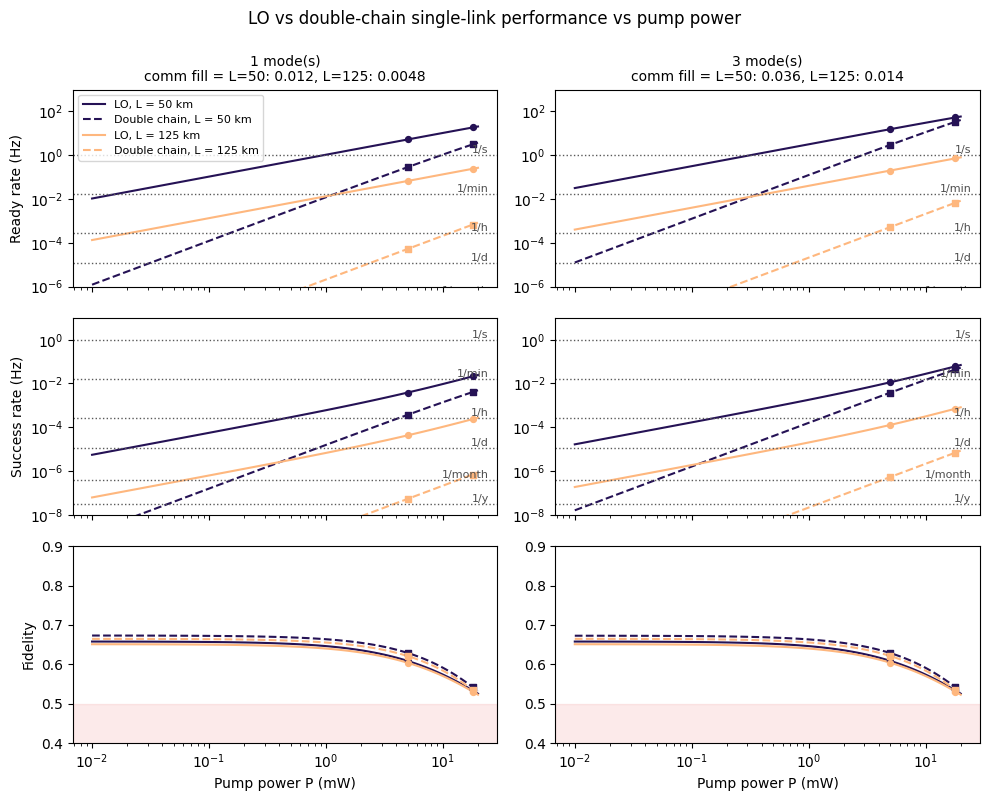

In [32]:
lo_dc_memory_modes = [1, 3]
lo_dc_L_scan = [50, 125]
lo_dc_P_scan = np.geomspace(0.01, 20, 120)
lo_dc_P_markers = [5, 18]
lo_dc_colors = plt.cm.magma(np.linspace(0.15, 0.85, len(lo_dc_L_scan)))

fig, axes = plt.subplots(3, len(lo_dc_memory_modes), figsize=(10, 8), sharex='col')

for col, memory_modes_now in enumerate(lo_dc_memory_modes):
    curves = lo_dc_collect_single_link_curves(lo_dc_P_scan, lo_dc_L_scan, memory_modes_now)
    for L_now, color in zip(lo_dc_L_scan, lo_dc_colors):
        for scheme in ('LO', 'Double chain'):
            style = lo_dc_scheme_styles[scheme]
            curve = curves[(scheme, L_now)]
            label = f'{scheme}, L = {L_now:g} km' if col == 0 else None

            axes[0, col].plot(curve['P'], curve['ready'], color=color, linestyle=style['linestyle'], label=label)
            axes[1, col].plot(curve['P'], curve['success'], color=color, linestyle=style['linestyle'])
            axes[2, col].plot(curve['P'], curve['fidelity'], color=color, linestyle=style['linestyle'])

            for P_marker in lo_dc_P_markers:
                if curve['P'][0] <= P_marker <= curve['P'][-1]:
                    axes[0, col].scatter(P_marker, np.interp(P_marker, curve['P'], curve['ready']), color=color, marker=style['marker'], s=18, zorder=3)
                    axes[1, col].scatter(P_marker, np.interp(P_marker, curve['P'], curve['success']), color=color, marker=style['marker'], s=18, zorder=3)
                    axes[2, col].scatter(P_marker, np.interp(P_marker, curve['P'], curve['fidelity']), color=color, marker=style['marker'], s=18, zorder=3)

            
    fill_text = ', '.join(
        f'L={L_now:g}: {memory_modes_now * params["T_acceptance"] / (2 * L_now * params["n"] / params["c"]):.2g}'
        for L_now in lo_dc_L_scan
    )
    axes[0, col].set_title(f'{memory_modes_now} mode(s)\ncomm fill = {fill_text}', fontsize=10)
    axes[0, col].set_yscale('log')
    axes[1, col].set_yscale('log')
    axes[1, col].set_ylim(bottom=1e-8)
    axes[2, col].set_ylim(0.4, 0.9)
    axes[0,col].set_ylim(bottom=1e-6, top=1e3)
    axes[1,col].set_ylim(bottom=1e-8, top=10)
    axes[2, col].axhspan(0, 0.5, color='lightcoral', alpha=0.16, zorder=0)
    axes[2, col].set_xlabel('Pump power P (mW)')
    lo_dc_add_rate_reference_lines(axes[0, col])
    lo_dc_add_rate_reference_lines(axes[1, col])
    for ax in axes[:, col]:
        ax.set_xscale('log')
        #for P_marker in lo_dc_P_markers:
        #    ax.axvline(P_marker, color='0.35', linestyle=':', linewidth=1)

axes[0, 0].set_ylabel('Ready rate (Hz)')
axes[1, 0].set_ylabel('Success rate (Hz)')
axes[2, 0].set_ylabel('Fidelity')
axes[0, 0].legend(fontsize=8)
fig.suptitle('LO vs double-chain single-link performance vs pump power', y=0.995)
plt.tight_layout()
plt.show()


#### Single-link rate-fidelity tradeoff

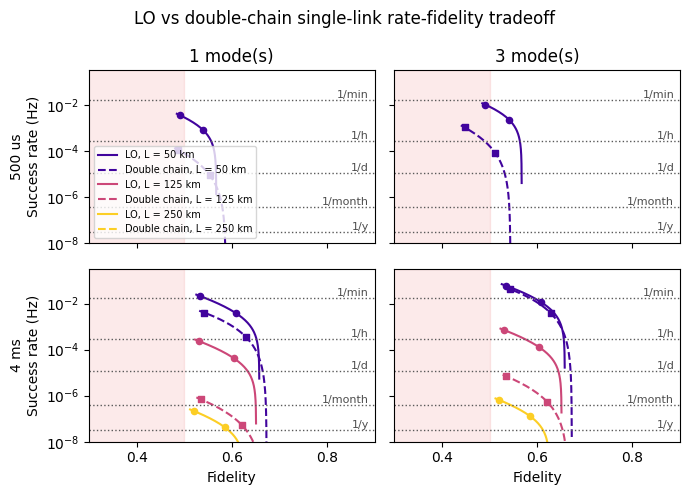

In [33]:
lo_dc_tradeoff_memory_modes = [1, 3]
lo_dc_tradeoff_tau_scans = [500e-6, 4e-3]
lo_dc_tradeoff_tau_labels = ['500 us', '4 ms']
lo_dc_tradeoff_L_scan = [50, 125, 250]
lo_dc_tradeoff_P_scan = np.geomspace(0.01, 20, 140)
lo_dc_tradeoff_P_markers = [5, 18]
lo_dc_tradeoff_colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(lo_dc_tradeoff_L_scan)))

fig, axes = plt.subplots(
    len(lo_dc_tradeoff_tau_scans),
    len(lo_dc_tradeoff_memory_modes),
    figsize=(7, 5),
    sharex=True,
    sharey=True,
)

for row, (tau_now, tau_label) in enumerate(zip(lo_dc_tradeoff_tau_scans, lo_dc_tradeoff_tau_labels)):
    for col, memory_modes_now in enumerate(lo_dc_tradeoff_memory_modes):
        ax = axes[row, col]
        curves = lo_dc_collect_single_link_curves(
            lo_dc_tradeoff_P_scan,
            lo_dc_tradeoff_L_scan,
            memory_modes_now,
            extra_params={'tau_eff': tau_now},
        )
        for L_now, color in zip(lo_dc_tradeoff_L_scan, lo_dc_tradeoff_colors):
            for scheme in ('LO', 'Double chain'):
                style = lo_dc_scheme_styles[scheme]
                curve = curves[(scheme, L_now)]
                label = f'{scheme}, L = {L_now:g} km' if row == 0 and col == 0 else None
                ax.plot(curve['fidelity'], curve['success'], color=color, linestyle=style['linestyle'], label=label)

                for P_marker in lo_dc_tradeoff_P_markers:
                    if curve['P'][0] <= P_marker <= curve['P'][-1]:
                        ax.scatter(
                            np.interp(P_marker, curve['P'], curve['fidelity']),
                            np.interp(P_marker, curve['P'], curve['success']),
                            color=color,
                            marker=style['marker'],
                            s=20,
                            zorder=3,
                        )

        if row == 0:
            ax.set_title(f'{memory_modes_now} mode(s)')
        if row == len(lo_dc_tradeoff_tau_scans) - 1:
            ax.set_xlabel('Fidelity')
        if col == 0:
            ax.set_ylabel(f'{tau_label}\nSuccess rate (Hz)')
        ax.set_xlim(0.3, 0.9)
        ax.set_yscale('log')
        ax.set_ylim(bottom=1e-8)
        ax.axvspan(0, 0.5, color='lightcoral', alpha=0.16, zorder=0)
        lo_dc_add_rate_reference_lines(ax)

axes[0, 0].legend(fontsize=7, loc='lower left')
fig.suptitle('LO vs double-chain single-link rate-fidelity tradeoff')
plt.tight_layout()
plt.show()


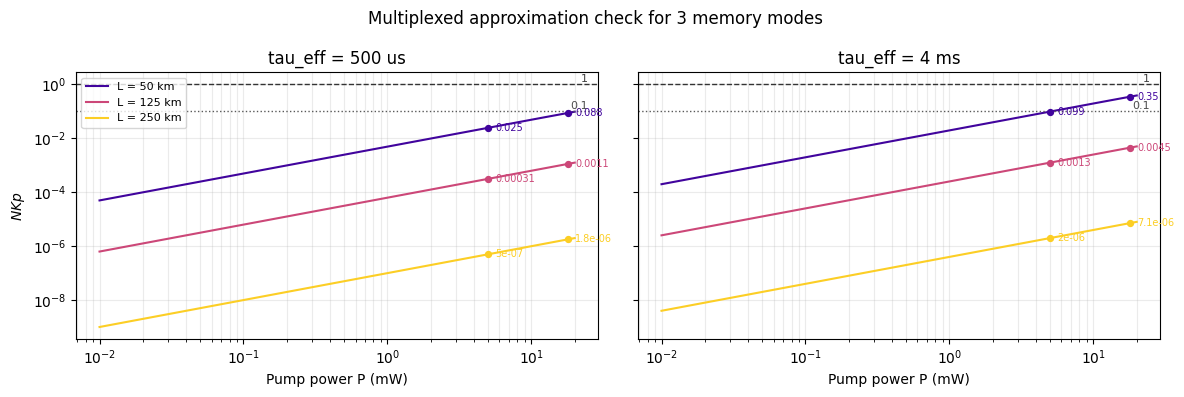

In [34]:
# Check the N*K*p numbers for the multiplexed double-chain approximation
knp_check_memory_modes = 3


def double_chain_knp(scan_params, memory_modes):
    link = DoubleChainLink(scan_params, memory_modes=memory_modes, print_rate=False)
    link.get_rates()
    N_rounds = link.params.T_max / (2 * link.params.T_L)
    return N_rounds * memory_modes * link.p


fig, axes = plt.subplots(
    1,
    len(lo_dc_tradeoff_tau_scans),
    figsize=(12, 4),
    sharey=True,
    squeeze=False,
)

for ax, tau_now, tau_label in zip(axes[0], lo_dc_tradeoff_tau_scans, lo_dc_tradeoff_tau_labels):
    for L_now, color in zip(lo_dc_tradeoff_L_scan, lo_dc_tradeoff_colors):
        knp_scan = []
        for P_now in lo_dc_tradeoff_P_scan:
            scan_params = params.copy()
            scan_params['P'] = P_now
            scan_params['L'] = L_now
            scan_params['tau_eff'] = tau_now
            knp_scan.append(double_chain_knp(scan_params, knp_check_memory_modes))

        knp_scan = np.asarray(knp_scan)
        ax.plot(lo_dc_tradeoff_P_scan, knp_scan, color=color, label=f'L = {L_now:g} km')

        for P_marker in lo_dc_tradeoff_P_markers:
            if lo_dc_tradeoff_P_scan[0] <= P_marker <= lo_dc_tradeoff_P_scan[-1]:
                knp_marker = np.interp(P_marker, lo_dc_tradeoff_P_scan, knp_scan)
                ax.scatter(P_marker, knp_marker, color=color, s=18, zorder=3)
                ax.annotate(
                    f'{knp_marker:.2g}',
                    xy=(P_marker, knp_marker),
                    xytext=(5, 0),
                    textcoords='offset points',
                    fontsize=7,
                    color=color,
                    va='center',
                )

    ax.axhline(0.1, color='0.35', linestyle=':', linewidth=1)
    ax.axhline(1, color='0.2', linestyle='--', linewidth=1)
    ax.text(0.98, 0.1, '0.1', transform=ax.get_yaxis_transform(), ha='right', va='bottom', fontsize=8, color='0.3')
    ax.text(0.98, 1, '1', transform=ax.get_yaxis_transform(), ha='right', va='bottom', fontsize=8, color='0.25')
    ax.set_title(f'tau_eff = {tau_label}')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Pump power P (mW)')
    ax.grid(True, which='both', alpha=0.25)

axes[0, 0].set_ylabel(r'$N K p$')
axes[0, 0].legend(fontsize=8, loc='upper left')
fig.suptitle(f'Multiplexed approximation check for {knp_check_memory_modes} memory modes')
plt.tight_layout()
plt.show()

#### Single-link distance reach at fixed pump power

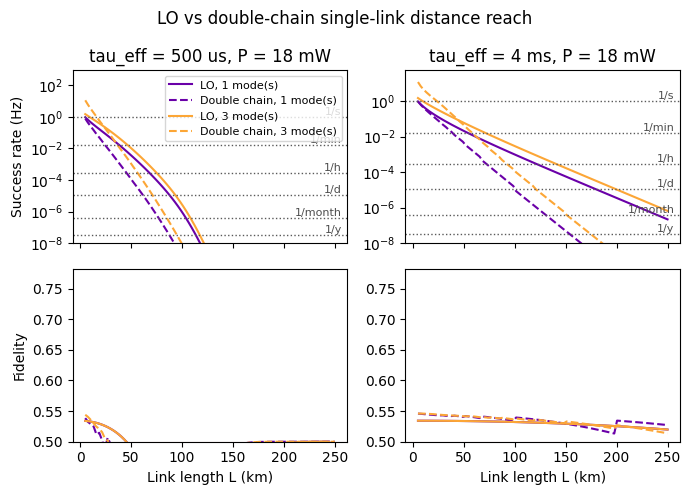

In [35]:
lo_dc_distance_P = 18
lo_dc_distance_tau_scans = [500e-6, 4e-3]
lo_dc_distance_tau_labels = ['500 us', '4 ms']
lo_dc_distance_memory_modes = [1, 3]
lo_dc_distance_L_scan = np.linspace(5, 250, 90)
lo_dc_distance_colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(lo_dc_distance_memory_modes)))

fig, axes = plt.subplots(2, len(lo_dc_distance_tau_scans), figsize=(7, 5), sharex='col')

for col, (tau_now, tau_label) in enumerate(zip(lo_dc_distance_tau_scans, lo_dc_distance_tau_labels)):
    for memory_modes_now, color in zip(lo_dc_distance_memory_modes, lo_dc_distance_colors):
        for scheme in ('LO', 'Double chain'):
            style = lo_dc_scheme_styles[scheme]
            success_scan = []
            F_scan = []
            for L_now in lo_dc_distance_L_scan:
                scan_params = params.copy()
                scan_params['P'] = lo_dc_distance_P
                scan_params['tau_eff'] = tau_now
                scan_params['L'] = L_now
                metrics = lo_dc_single_link_metrics(scheme, scan_params, memory_modes=memory_modes_now)
                success_scan.append(metrics['success'])
                F_scan.append(metrics['fidelity'])

            label = f'{scheme}, {memory_modes_now} mode(s)' if col == 0 else None
            axes[0, col].plot(lo_dc_distance_L_scan, success_scan, color=color, linestyle=style['linestyle'], label=label)
            axes[1, col].plot(lo_dc_distance_L_scan, F_scan, color=color, linestyle=style['linestyle'])

    axes[0, col].set_title(f'tau_eff = {tau_label}, P = {lo_dc_distance_P:g} mW')
    axes[0, col].set_yscale('log')
    axes[0, col].set_ylim(bottom=1e-8)
    lo_dc_add_rate_reference_lines(axes[0, col])
    axes[1, col].set_ylim(0, 1.02)
    axes[1, col].axhspan(0, 0.5, color='lightcoral', alpha=0.16, zorder=0)
    axes[1, col].set_xlabel('Link length L (km)')

axes[1, 0].set_ylim(0.5, 0.782)
axes[1, 1].set_ylim(0.5, 0.782)
axes[0, 0].set_ylabel('Success rate (Hz)')
axes[1, 0].set_ylabel('Fidelity')
axes[0, 0].legend(fontsize=8)
fig.suptitle('LO vs double-chain single-link distance reach')
plt.tight_layout()
plt.show()


# A single chain exampke : Swappinger

#### Single chain class

In [9]:
class SingleChain:
    def __init__(self, params, memory_modes = 1,print_rate = False):
        self.params = SimpleNamespace(**params)
        self.calculate_params()
        self.print_rate = print_rate
        self.memory_modes = memory_modes

    def calculate_params(self):
        """Calculate parameters that depend on other parameters."""
        self.params.eta_m0 = self.params.eta_AFC0 * self.params.eta_CP**2
        self.params.eta_duty_mem = 1 - self.params.prep_mem / self.params.cycle_mem
        self.params.Rid0 = self.params.bright / self.params.M
        self.params.g2 = 1 +  1 / (self.params.a * self.params.P)
        self.params.T_max = max(self.params.tau_eff * 0.5, 500e-6)
        self.params.NF = self.params.mu1 * self.params.eta_T2 * self.params.eta_T3 * self.params.eta_d * self.params.eta_m0

        # SWAPPINGER
        self.params.eta_path =self.params.eta_T1 * self.params.eta_T2 * self.params.eta_T3

        self.params.fib = 10 ** (-self.params.alpha * self.params.L / 10)
        self.params.T_L = self.params.L * self.params.n / self.params.c

    # time dependent functions

    def efficiency(self, t):
        storage_time = 2 * self.params.T_L + t
        return self.params.eta_m0 * np.exp(-storage_time**2 / self.params.tau_eff**2)

    def g2_sw(self, t):
        """Cross-correlation function as a function of storage time."""
        # 
        return 1 + self.params.eta_h * self.efficiency(t) * self.params.eta_T2 * self.params.eta_T3 * self.params.eta_d / (self.params.eta_h * self.params.eta_AFC0 * self.params.eta_T2 * self.params.eta_T3 * self.params.eta_d / self.params.g2 + self.params.NF)

    def g2_sw_dario(self, t):
        """Cross-correlation function as a function of storage time."""
        # No stored signal means uncorrelated detections, so g2 tends to 1.
        return self.params.eta_h * self.efficiency(t) * self.params.eta_path * self.params.eta_d / (self.params.eta_h * self.params.eta_AFC0 * self.params.eta_path * self.params.eta_d / self.params.g2 + self.params.NF)

    def g2_sw_prx(self,t):
        return self.params.g2 * (self.params.eta_h * self.efficiency(t) * self.params.eta_T2 * self.params.eta_T3 * self.params.eta_d / self.params.NF + 1) / (self.params.g2 + self.params.eta_h * self.efficiency(t) * self.params.eta_T2 * self.params.eta_T3 * self.params.eta_d / self.params.NF)

    def V(self, t):
        """Visibility as a function of storage time."""
        return (self.g2_sw_prx(t) - 1) / (self.g2_sw_prx(t) + 1) * np.exp(- (self.params.sigma_phase**2) /2 ) * self.params.etaOv **2 * self.params.etaclass  
    
    def p10(self, t):
        """Probability to detect a photon on the left of the link, and no photon on the right, conditioned on idler detection."""
        return self.efficiency(t) * self.params.eta_path * self.params.eta_d * self.params.eta_h / 2 + self.params.NF

    def p01(self, t):
        return self.p10(t)

    def p11(self, t):
        """Probability to detect a photon on the left of the link, and a photon on the right, conditioned on idler detection."""
        return 4 * self.p10(t) * self.p10(t) * (self.g2_sw(t) - 1) / (self.g2_sw(t) * self.g2_sw(t))

    def p00(self, t):
        return np.maximum(1 - self.p01(t) - self.p10(t) - self.p11(t), 0)

    def detected_single_weight(self, t):
        return self.p01(t) + self.p10(t)

    def q_pop(self, t):
        """ Part of the density matrix population in the |10><10| and |01><01| subspace, conditioned on idler detection. No vacuum there"""
        return (2 * self.p10(t))/(2 * self.p10(t) + self.p11(t))
    
    def concurrence(self, t):
        """Concurrence of the state conditioned on idler detection."""
        return max(0, self.V(t)*(self.p10(t) * 2) - 2 * np.sqrt(self.p00(t) * self.p11(t)))

    def get_rates(self, t=0):
        self.N = np.floor(self.params.T_max / 2 / self.params.T_L)                  # Number of rounds before giving up
        self.Gamma_1 = self.params.Rid0 * self.params.P * self.params.fib * self.params.eta_d * 2     # heralding rate of idlers in central station
        self.p = 1 - np.exp(- self.Gamma_1 * self.params.T_acceptance)       # Probability of at least one heralding event in T_acceptance
        self.q = 1 - self.p                                                              # Probability of no heralding event in T_acceptance

        self.T_cycle = self.params.T_acceptance + (16.5e-6 + self.params.lat) * self.p 
        
        self.Gamma_ready = self.p / self.T_cycle * self.params.eta_duty_mem * self.params.eta_duty_chopper * self.params.eta_phase_stab

        # Overall success rate
        self.Gamma_succ = self.Gamma_ready * ( self.p01(t) + self.p10(t) )
    
        if self.print_rate:
            print(f"Ready rate: {self.Gamma_ready:.2f} Hz")
            print(f"Success rate: {self.Gamma_succ:.4f} Hz")

    def get_fidelity(self, t=0):
        self.fidelity = self.q_pop(t) * (1 + self.V(t)) / 2

        if self.print_rate:
            print(f"Fidelity: {self.fidelity:.4f}")

    def plot_concurrence_vs_time(self, tend = 50e-6, swappinger_data = True):
        t_scan = np.linspace(0, tend, 200)
        concurrence_scan = np.array([self.concurrence(t) for t in t_scan])

        swappinger_st = [16e-6, 20e-6, 25e-6, 30e-6, 35e-6]
        swappinger_conc = [1.45e-4, 0.58e-4, 0.05e-4, 0, 0]
        swapping_conc_err = [0.3e-4, 0.17e-4, 0.1e-4, 0, 0]

        fig, ax = plt.subplots(figsize=(6, 4))
        ax.plot(t_scan * 1e6 + 6.5e-6 * 1e6, concurrence_scan, color = "#e9da58")
        if swappinger_data:
            plt.errorbar(np.array(swappinger_st)*1e6, swappinger_conc, yerr=swapping_conc_err, fmt='o', color="#f1dc1c", markerfacecolor="#f7f0b4", label='Haenni et al. (PRX 2025)')
        ax.set_xlabel('Storage time (us)')
        ax.set_ylabel('Concurrence')
        ax.set_title('Concurrence vs storage time')
        ax.legend()
        return fig, ax

    def plot_efficiency_vs_time(self, tend = 50e-6):
        t_scan = np.linspace(0, tend, 200)
        efficiency_scan = np.array([self.efficiency(t) for t in t_scan])


        fig, ax = plt.subplots(figsize=(6, 4))
        ax.plot(t_scan * 1e3, efficiency_scan)
        ax.set_xlabel('Storage time (ms)')
        ax.set_ylabel('Efficiency')
        ax.set_title('Efficiency vs storage time')
        return fig, ax

In [5]:
params_swappinger = {
    "eta_AFC0": 0.11,
    "eta_CP": 0.7,
    "eta_swappinger": 4e-2,
    "cycle_mem": cycle_mem,
    "prep_mem": 0.6,
    "T_acceptance": 6e-6,
    "lat": 200e-6,
    "NF": 5e-5,
    "tau_eff": 25e-6,
    "eta_h": 0.25,
    "P": 3.55,
    "a": 0.00315,
    "bright": 24300,
    "M": M,
    "eta_duty_chopper": 18/33,
    "eta_phase_stab": eta_phase_stab,
    "T_max": T_max,
    "eta_T1": 0.6,
    "eta_T2": 0.1,
    "eta_T3": 0.9,
    "etaOv": 0.9,
    "eta_d": 0.8,
    "L": 0.001,
    "t_bin": 100e-9,
    "alpha": alpha,
    "c": c,
    "n": n,
    "sigma_phase": 0.7 / 2.355,
    "etaclass": etaclass,
    "etapath": 0.1,     # swappinger
    "mu1": 0.01,        # swappinger
}

Ready rate: 498.57 Hz
Success rate: 0.3289 Hz
Fidelity: 0.8055
g2_SW: 16.98
g2_SW_dario: 11.21
g2_SW_prx: 20.37
g2_source: 90.43
Visibility: 0.611
V_DFG_class: 0.9567857554868169
p10 : 3.2987e-04
p11 : 2.4120e-08
Heralding rate: 9201.176260417205
noise floor: 3.88e-05


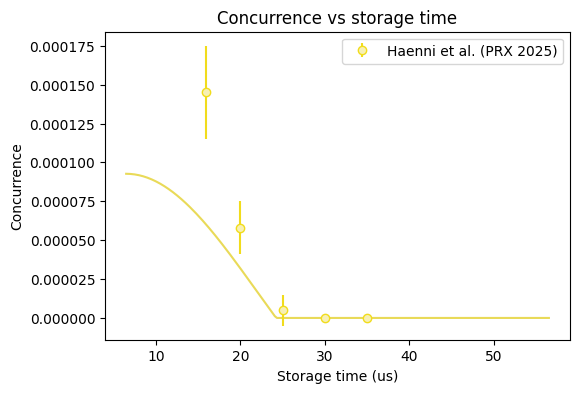

In [10]:
mySingleChain = SingleChain(params_swappinger, memory_modes=1, print_rate=True)
mySingleChain.get_rates(t=0)
mySingleChain.get_fidelity(t=0)
print(f"g2_SW: {mySingleChain.g2_sw(0):.2f}")
print(f"g2_SW_dario: {mySingleChain.g2_sw_dario(0):.2f}")
print(f"g2_SW_prx: {mySingleChain.g2_sw_prx(0):.2f}")
print(f"g2_source: {mySingleChain.params.g2:.2f}")
print(f"Visibility: {mySingleChain.V(0):.3f}")
print(f"V_DFG_class: {np.exp(- (mySingleChain.params.sigma_phase**2) /2 )}")
print(f"p10 : {mySingleChain.p10(0):.4e}")
print(f"p11 : {mySingleChain.p11(0):.4e}")
print(f"Heralding rate: {mySingleChain.Gamma_1}")
print(f"noise floor: {mySingleChain.params.NF:.2e}")
fig, ax = mySingleChain.plot_concurrence_vs_time()

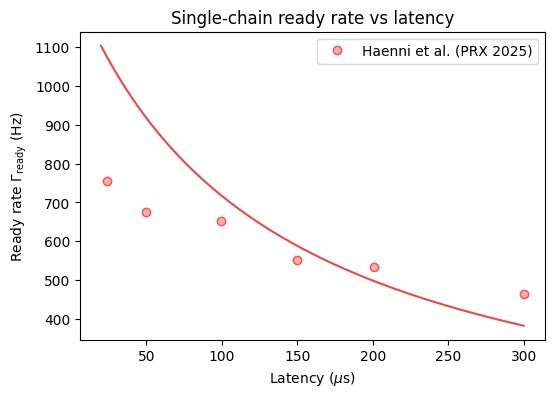

In [11]:
# Gamma_ready as a function of latency for the single chain
single_chain_lat_scan_us = np.linspace(20, 300, 250)
single_chain_ready_scan = []

for lat_now_us in single_chain_lat_scan_us:
    scan_params = params_swappinger.copy()
    scan_params["lat"] = lat_now_us * 1e-6
    mylink = SingleChain(scan_params, memory_modes=1, print_rate=False)
    mylink.get_rates(t=0)
    single_chain_ready_scan.append(mylink.Gamma_ready)

single_chain_ready_scan = np.array(single_chain_ready_scan)
lat_marker_us = params_swappinger["lat"] * 1e6
ready_at_marker = np.interp(lat_marker_us, single_chain_lat_scan_us, single_chain_ready_scan)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(single_chain_lat_scan_us, single_chain_ready_scan, color="#ec4848")
ax.set_xlabel(r"Latency ($\mu$s)")
ax.set_ylabel(r"Ready rate $\Gamma_{\mathrm{ready}}$ (Hz)")
ax.set_title("Single-chain ready rate vs latency")
#ax.set_yscale("log")
add_rate_reference_lines(ax)

icfo_data_x = [24.02234636871505, 49.72067039106142, 99.62756052141526, 149.9068901303538, 200.93109869646182, 300]
icfo_data_y = [755.5555555555557, 674.2690058479533, 651.4619883040937, 550.8771929824561, 534.5029239766081, 463.7426900584796]

ax.plot(icfo_data_x, icfo_data_y, color="#ff4c4c", markerfacecolor="#faaeae", marker="o", linestyle="None", label="Haenni et al. (PRX 2025)")
ax.legend()
plt.show()

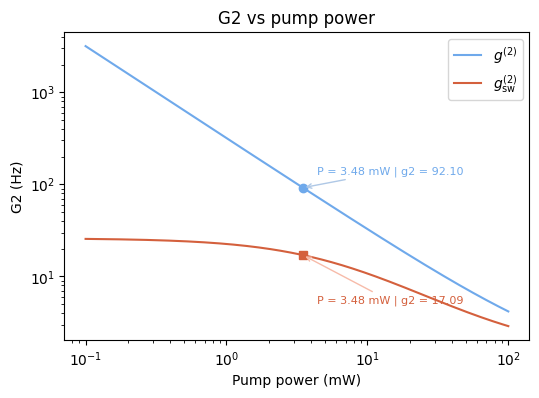

In [8]:
# g2 source and g2 sw vs p
p_scan = np.logspace(-1, 2, 250)
g2_source_scan = []
g2_sw_scan = []
annotate = 128
for p_pump in p_scan:
    scan_params = params_swappinger.copy()
    scan_params["P"] = p_pump
    mylink = SingleChain(scan_params, memory_modes=1, print_rate=False)
    mylink.get_rates(t=0)
    g2_source_scan.append(mylink.params.g2)
    g2_sw_scan.append(mylink.g2_sw(0))

g2_source_scan = np.array(g2_source_scan)
g2_sw_scan = np.array(g2_sw_scan)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(p_scan, g2_source_scan, color="#6fa9eb", label="$g^{(2)}$")
ax.plot(p_scan, g2_sw_scan, color="#d4603d", label="$g^{(2)}_{\\text{sw}}$")
ax.set_xlabel(r"Pump power (mW)")
ax.set_ylabel(r"G2 (Hz)")
ax.set_title("G2 vs pump power")
ax.set_yscale("log")
ax.set_xscale("log")
ax.plot(p_scan[annotate], g2_source_scan[annotate], marker="o", color="#6fa9eb")
ax.plot(p_scan[annotate], g2_sw_scan[annotate], marker="s", color="#d4603d")
ax.legend()
ax.annotate(
    f"P = {p_scan[annotate]:.2f} mW | g2 = {g2_source_scan[annotate]:.2f}",
    xy=(p_scan[annotate], g2_source_scan[annotate]),
    xytext=(10, 10),
    textcoords="offset points",
    fontsize=8,
    color="#6fa9eb",
    arrowprops=dict(arrowstyle="->", color="#afc8e6"),
)
ax.annotate(
    f"P = {p_scan[annotate]:.2f} mW | g2 = {g2_sw_scan[annotate]:.2f}",
    xy=(p_scan[annotate], g2_sw_scan[annotate]),
    xytext=(10, -35),
    textcoords="offset points",
    fontsize=8,
    color="#d4603d",
    arrowprops=dict(arrowstyle="->", color="#f7bba9"),
)
plt.show()